# REP — Historical Reference Model

| | |
|---|---|
| **Notebook** | `REP__historical_reference_model.ipynb` |
| **Description** | Builds analyte-specific historical reference models for Replicate QC samples using spline quantile regression of RPD against mean concentration. |
| **Author** | Rob Clark |
| **Created** | August 2026 / Semester 2 |
| **QC Type** | Replicate |

## Change History

| Date | Author | Description |
|---|---|---|
| 2026-08-30 | R.Clark | (T32-141/T32-232) Developed historical reference model for all eligible Replicate analytes using Q25, Q50, Q75 and Q95. |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Load prepared Replicate QC dataset
df = pd.read_csv("../data/processed/replicates_model.csv")

df.head()


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_VALUE,UNIT_CODE
0,2021-11-22 16:37:52.000000,PB,1385.198107,1492.268392,1.25,1438.733250,107.070285,7.44,Warning,10,MG_KG
1,2021-11-22 16:37:33.000000,NI,16.334782,18.525452,5.00,17.430117,2.190670,12.57,Pass,10,MG_KG
2,2021-11-22 16:35:49.000000,AG,14.647905,14.901179,0.05,14.774542,0.253274,1.71,Pass,10,MG_KG
3,2021-11-22 16:35:49.000000,CU,18891.143085,19641.928358,5.00,19266.535721,750.785274,3.90,Pass,10,MG_KG
4,2021-11-22 16:35:49.000000,ZN,2340.890959,2419.042385,12.50,2379.966672,78.151426,3.28,Pass,10,MG_KG


In [4]:
# Historical reference population
accepted_statuses = ["Pass", "IgnoreFailure"]

df_reference = df[
    (df["RPD"] > 0) &
    (df["PRECISION_STATUS"].isin(accepted_statuses)) &
    (df["MEAN_CONC"] > 0)
].copy()


In [5]:
# Dynamically identify all analytes available in the historical reference population
MODEL_ANALYTES = sorted(
    df_reference["ANALYTE_CODE"]
    .dropna()
    .unique()
    .tolist()
)

print(f"Analytes discovered: {len(MODEL_ANALYTES)}")
print(", ".join(MODEL_ANALYTES))


Analytes discovered: 58
AG, AL, AS, BA, BE, BI, CA, CD, CE, CO, CR, CS, CU, DY, ER, EU, FE, GA, GD, GE, HF, HO, IN, K, LA, LI, LU, MG, MN, MO, NB, ND, NI, P, PB, PR, RB, S, SB, SC, SE, SM, SN, SR, TA, TB, TE, TH, TI, TL, TM, U, V, W, Y, YB, ZN, ZR


In [6]:
import statsmodels.formula.api as smf
from patsy import bs

# Add log-transformed concentration to the full historical reference population
df_reference = df_reference.copy()

df_reference["LOG_MEAN_CONC"] = np.log10(
    df_reference["MEAN_CONC"]
)

# Quantiles used by the historical reference model
quantiles = [0.25, 0.50, 0.75, 0.95]

print(f"Reference observations: {len(df_reference):,}")
print(f"Analytes available: {df_reference['ANALYTE_CODE'].nunique()}")


Reference observations: 28,194
Analytes available: 58


In [11]:
# Fit spline quantile regression models for all analytes

import warnings
from statsmodels.tools.sm_exceptions import IterationLimitWarning

all_spline_models = {}
model_fit_summary = []

for analyte in MODEL_ANALYTES:

    # Select observations for the current analyte
    df_analyte = (
        df_reference[
            df_reference["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    analyte_models = {}

    for q in quantiles:

        iteration_warning = False

        with warnings.catch_warnings(record=True) as caught_warnings:
            warnings.simplefilter("always", IterationLimitWarning)

            model = smf.quantreg(
                "RPD ~ bs(LOG_MEAN_CONC, df=4, degree=3)",
                df_analyte
            ).fit(
                q=q,
                max_iter=10000
            )

            # Check whether this fit reached the iteration limit
            iteration_warning = any(
                issubclass(w.category, IterationLimitWarning)
                for w in caught_warnings
            )

        analyte_models[q] = model

        model_fit_summary.append({
            "ANALYTE_CODE": analyte,
            "OBSERVATIONS": len(df_analyte),
            "QUANTILE": f"Q{int(q * 100):02d}",
            "ITERATION_WARNING": iteration_warning
        })

    # Store fitted models by analyte
    all_spline_models[analyte] = analyte_models

    print(
        f"{analyte}: "
        f"{len(df_analyte):,} observations — "
        f"Q25, Q50, Q75, Q95 fitted"
    )

# Create model-fit diagnostic table
model_fit_summary_df = pd.DataFrame(model_fit_summary)

print(
    f"\nCompleted models for "
    f"{len(all_spline_models)} analytes."
)

# Report any models that still reached the iteration limit
warning_models = model_fit_summary_df[
    model_fit_summary_df["ITERATION_WARNING"]
]

if len(warning_models) == 0:
    print("All quantile models converged within the iteration limit.")
else:
    print(
        f"\nWARNING: {len(warning_models)} model fit(s) "
        f"reached the iteration limit:"
    )
    display(warning_models)
    

AG: 1,731 observations — Q25, Q50, Q75, Q95 fitted
AL: 211 observations — Q25, Q50, Q75, Q95 fitted
AS: 1,466 observations — Q25, Q50, Q75, Q95 fitted
BA: 281 observations — Q25, Q50, Q75, Q95 fitted
BE: 341 observations — Q25, Q50, Q75, Q95 fitted
BI: 1,192 observations — Q25, Q50, Q75, Q95 fitted
CA: 243 observations — Q25, Q50, Q75, Q95 fitted
CD: 195 observations — Q25, Q50, Q75, Q95 fitted
CE: 230 observations — Q25, Q50, Q75, Q95 fitted
CO: 338 observations — Q25, Q50, Q75, Q95 fitted
CR: 239 observations — Q25, Q50, Q75, Q95 fitted
CS: 117 observations — Q25, Q50, Q75, Q95 fitted
CU: 1,665 observations — Q25, Q50, Q75, Q95 fitted
DY: 82 observations — Q25, Q50, Q75, Q95 fitted
ER: 86 observations — Q25, Q50, Q75, Q95 fitted
EU: 85 observations — Q25, Q50, Q75, Q95 fitted
FE: 1,142 observations — Q25, Q50, Q75, Q95 fitted
GA: 78 observations — Q25, Q50, Q75, Q95 fitted
GD: 82 observations — Q25, Q50, Q75, Q95 fitted
GE: 2 observations — Q25, Q50, Q75, Q95 fitted
HF: 170 observati

In [12]:
# Generate spline prediction tables for all analytes

prediction_tables = []

for analyte in MODEL_ANALYTES:

    # Select observations for the current analyte
    df_analyte = (
        df_reference[
            df_reference["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    # Create prediction grid across the observed concentration range
    x_grid = np.linspace(
        df_analyte["LOG_MEAN_CONC"].min(),
        df_analyte["LOG_MEAN_CONC"].max(),
        300
    )

    analyte_prediction_df = pd.DataFrame({
        "ANALYTE_CODE": analyte,
        "LOG_MEAN_CONC": x_grid
    })

    # Convert back to original concentration scale
    analyte_prediction_df["MEAN_CONC"] = (
        10 ** analyte_prediction_df["LOG_MEAN_CONC"]
    )

    # Generate fitted spline quantile values
    for q in quantiles:
        analyte_prediction_df[f"Q{int(q * 100):02d}"] = (
            all_spline_models[analyte][q].predict(
                analyte_prediction_df
            )
        )

    prediction_tables.append(analyte_prediction_df)

# Combine all analyte prediction tables
reference_model_df = pd.concat(
    prediction_tables,
    ignore_index=True
)

print(
    f"Reference model rows: {len(reference_model_df):,}"
)
print(
    f"Analytes represented: "
    f"{reference_model_df['ANALYTE_CODE'].nunique()}"
)

reference_model_df.head()


Reference model rows: 17,400
Analytes represented: 58


,ANALYTE_CODE,LOG_MEAN_CONC,MEAN_CONC,Q25,Q50,Q75,Q95
0,AG,-2.569696,0.002693,204.010699,399.250001,1666.223325,2711.665895
1,AG,-2.553882,0.002793,199.380816,390.529976,1628.543695,2655.670244
2,AG,-2.538068,0.002897,194.822376,381.941392,1591.439697,2600.482214
3,AG,-2.522254,0.003004,190.334832,373.483253,1554.906935,2546.095864
4,AG,-2.506441,0.003116,185.917632,365.154560,1518.941014,2492.505251


In [13]:
# Corporate / professional chart palette
OBS_COLOUR = "#5B9BD5"       # historical observations
QUANTILE_COLOUR = "#5B6573"  # Q1 and Q3
MEDIAN_COLOUR = "#1F4E79"    # median - dark corporate blue
P95_COLOUR = "#A33A3A"       # muted red - exception / warning threshold
IQR_COLOUR = "#AFC6DB"       # subtle blue-grey shading


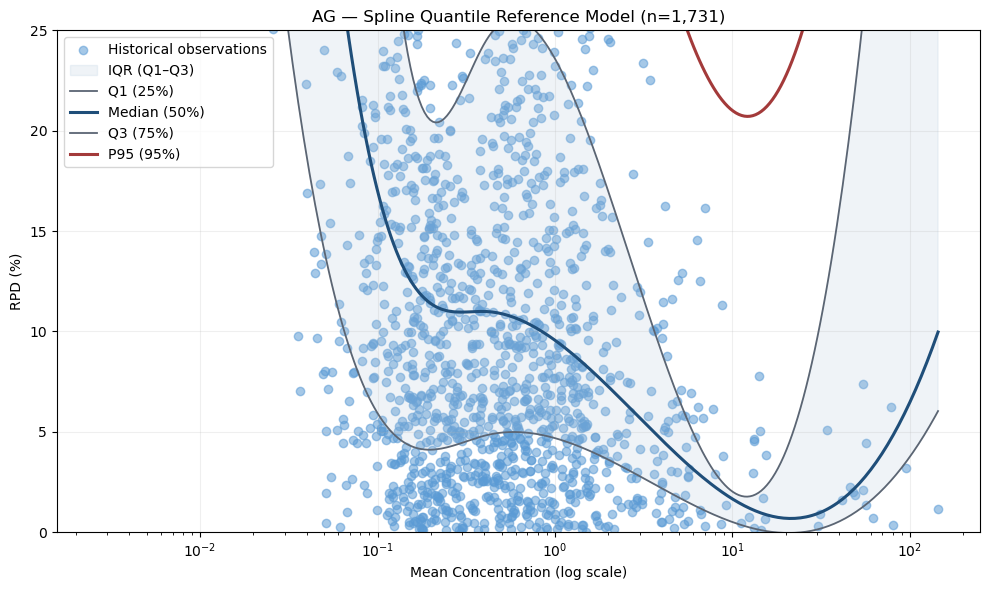

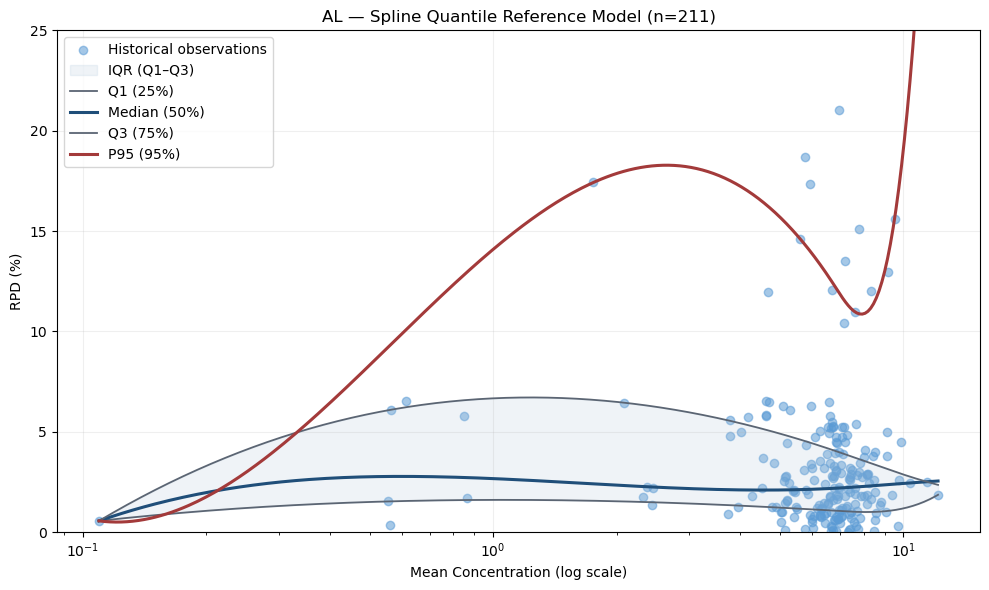

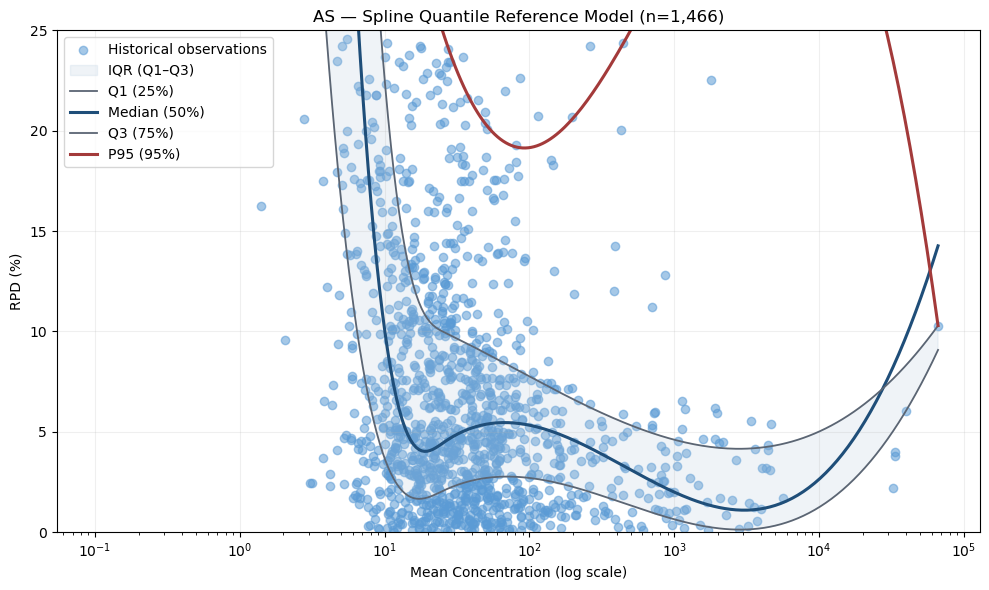

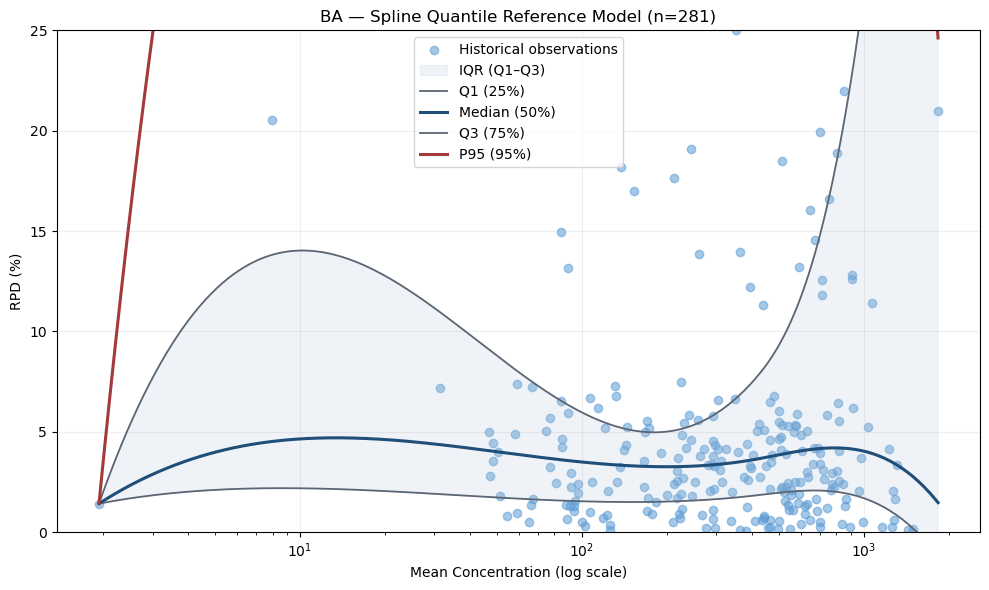

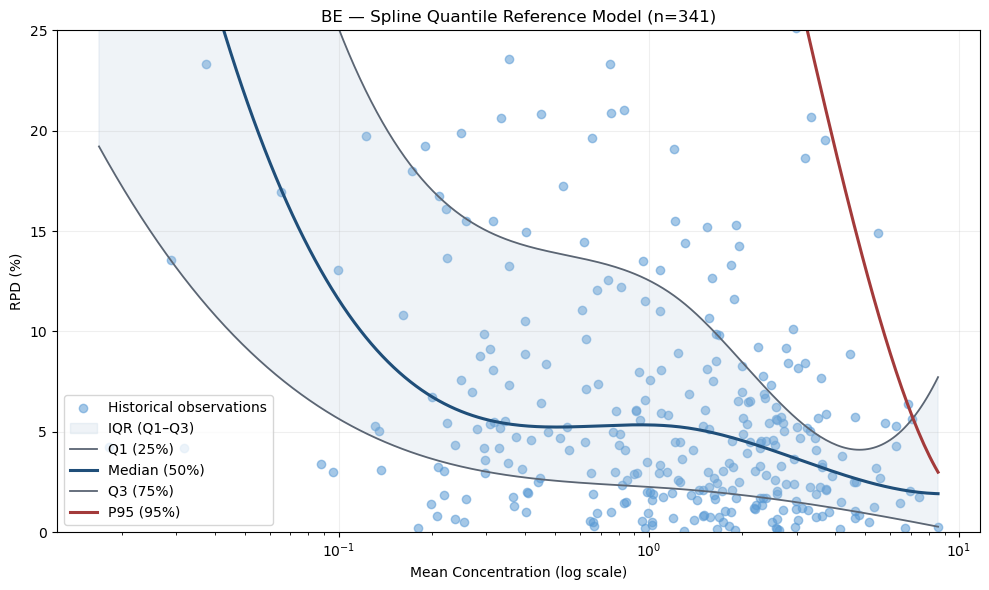

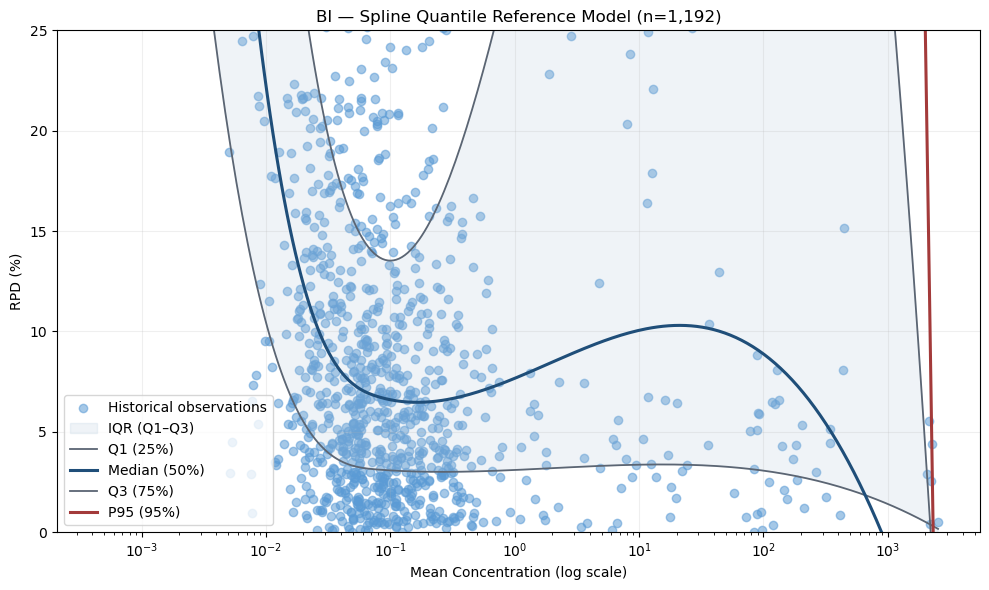

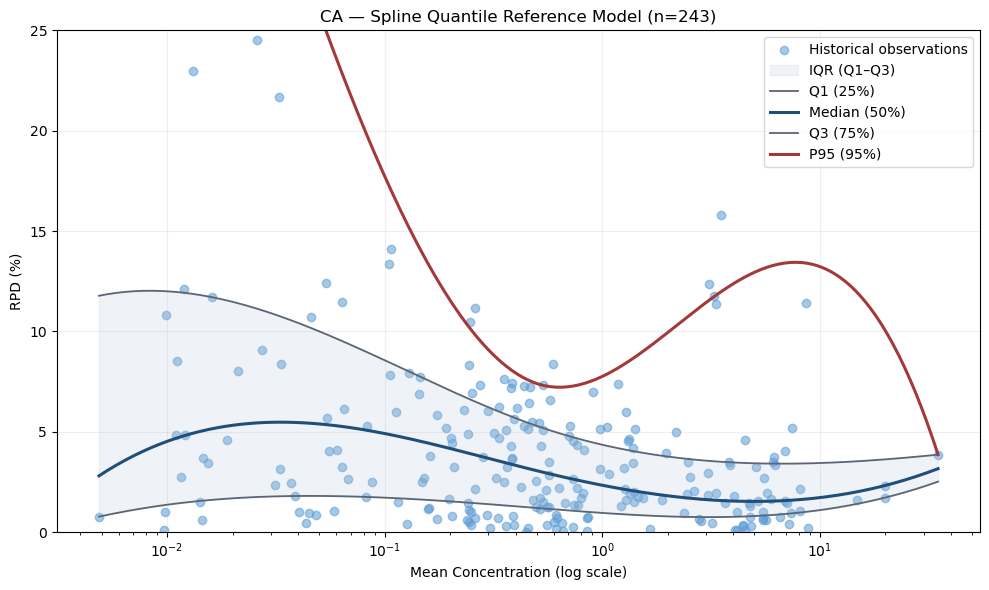

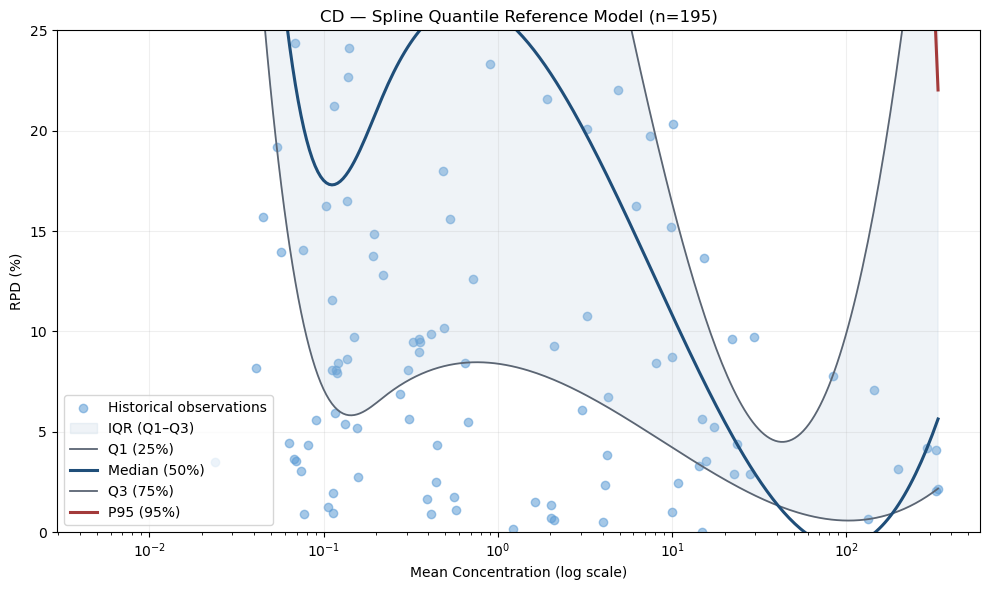

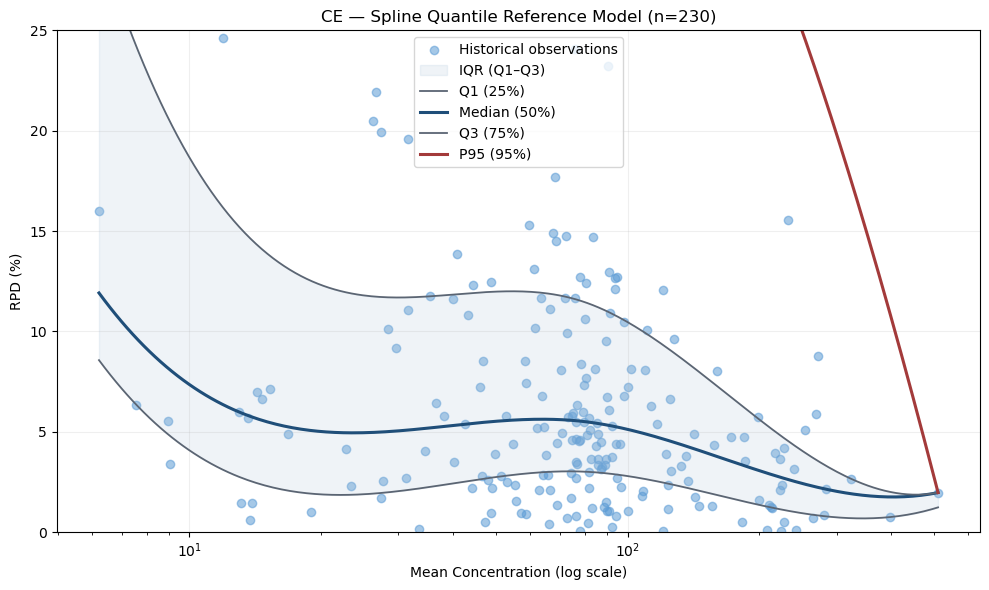

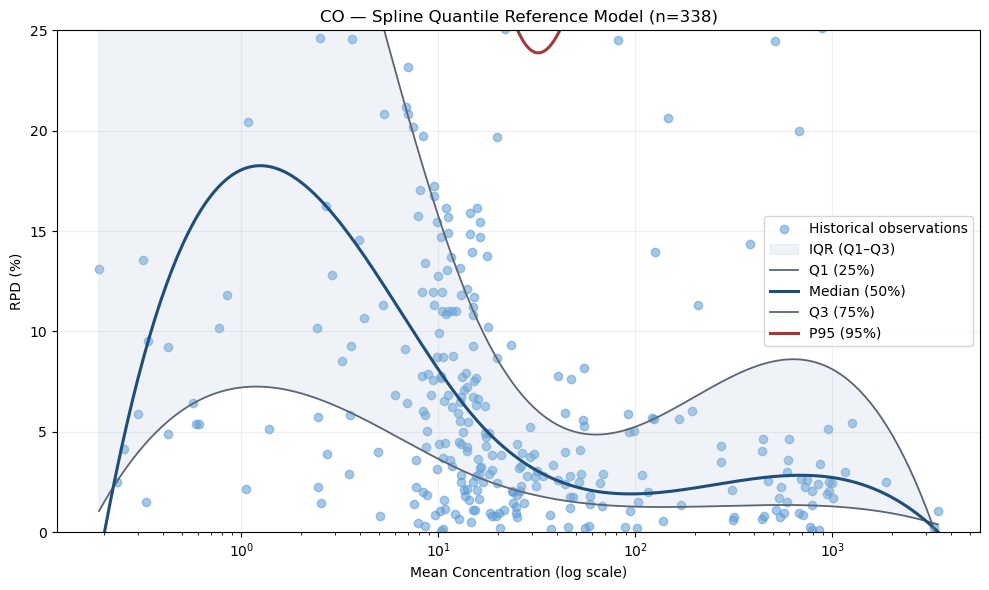

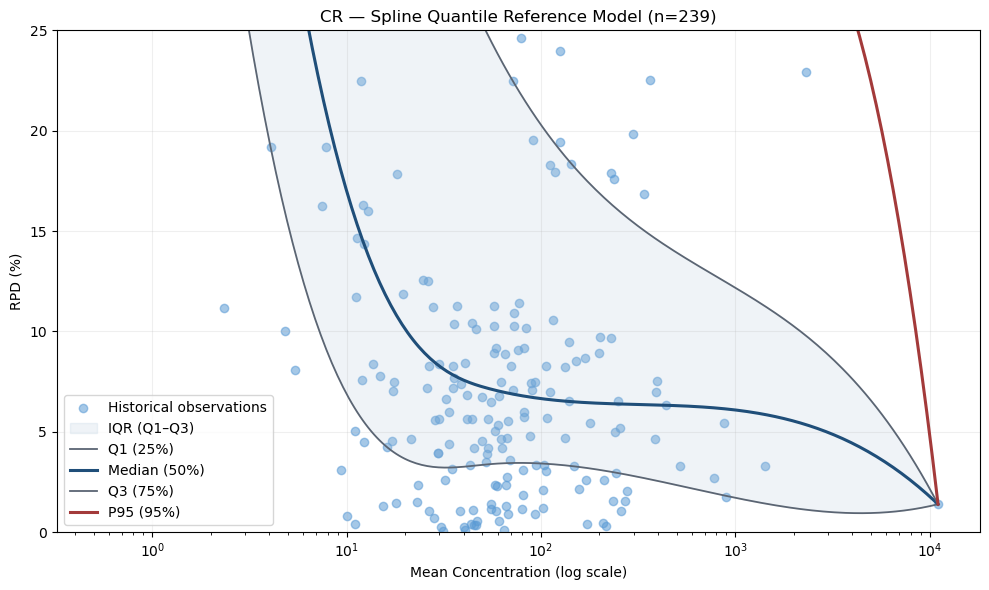

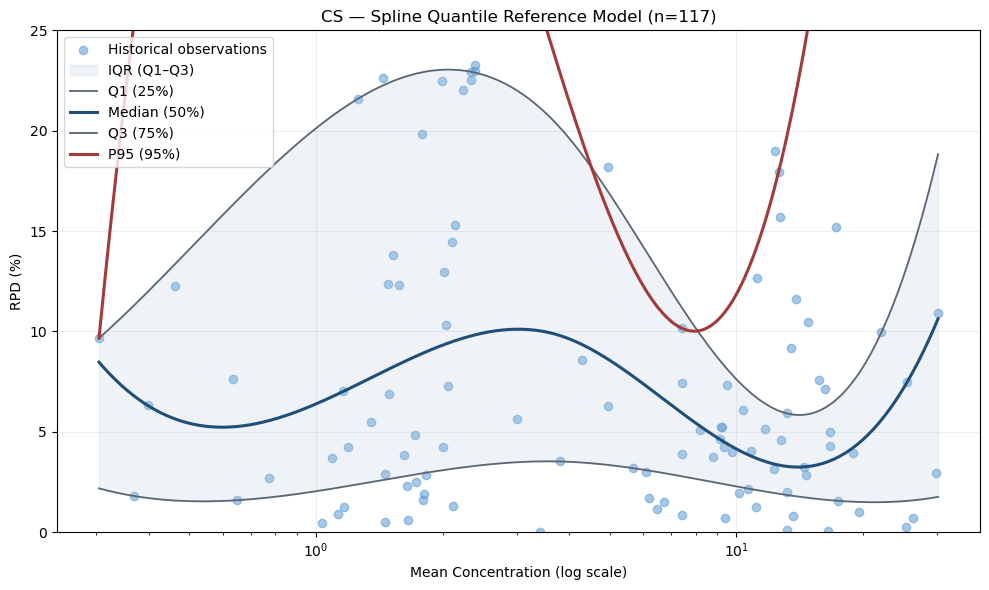

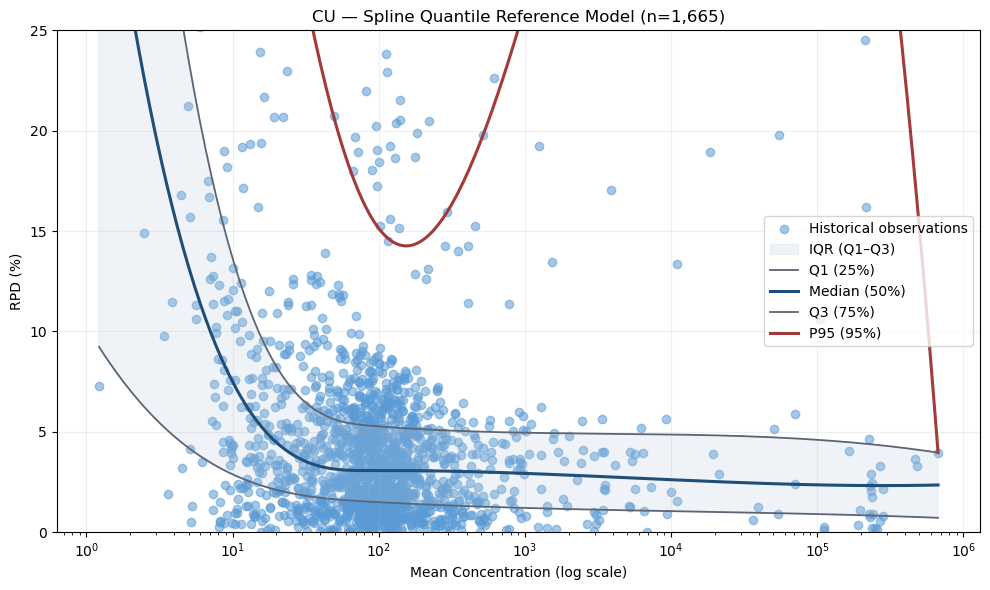

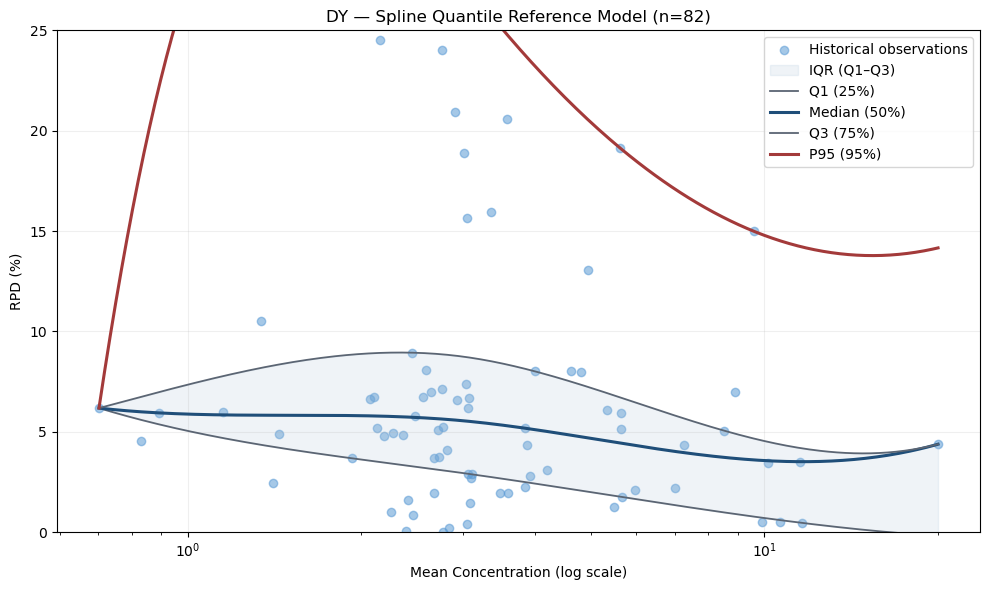

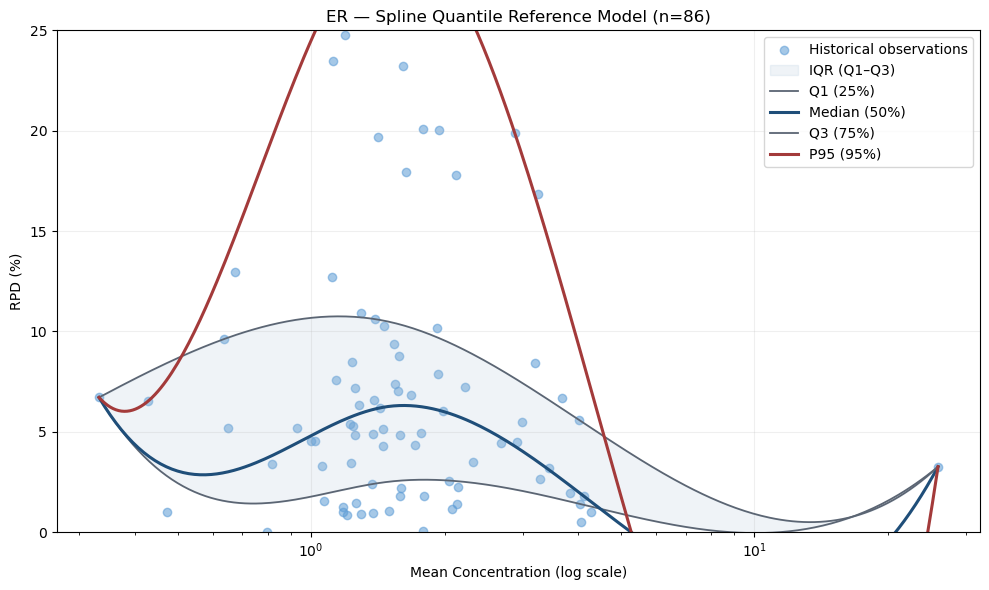

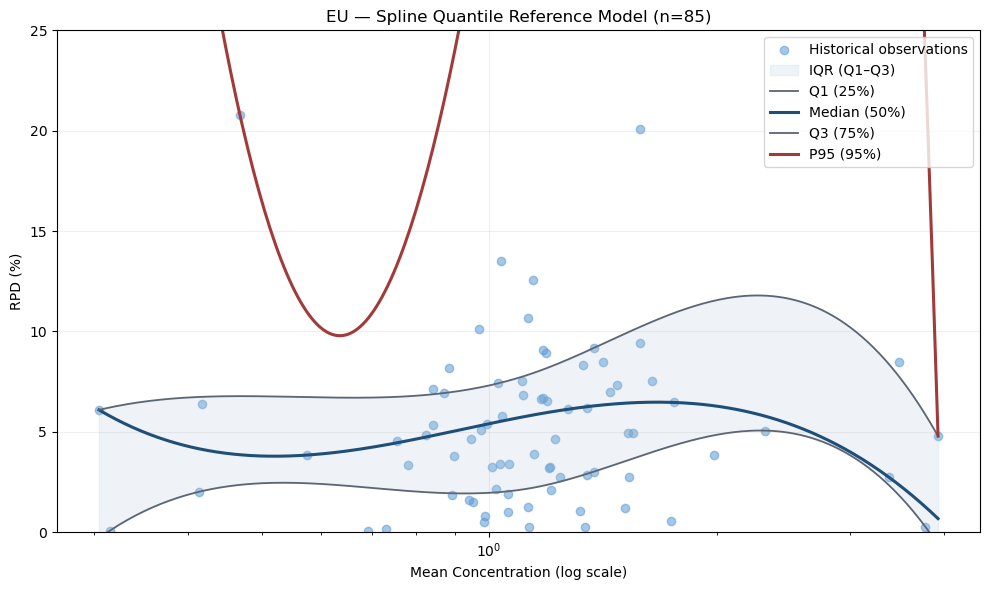

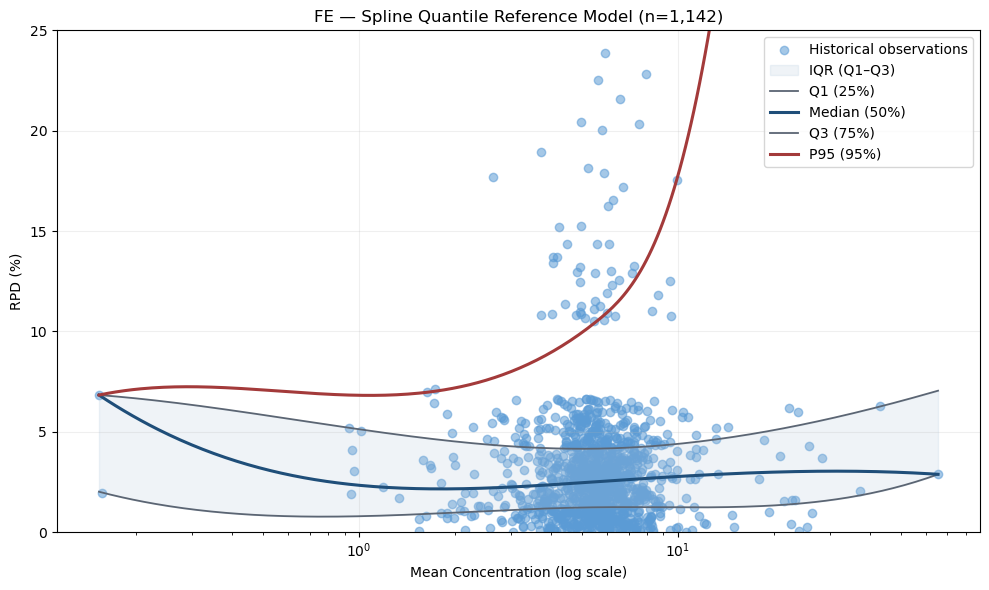

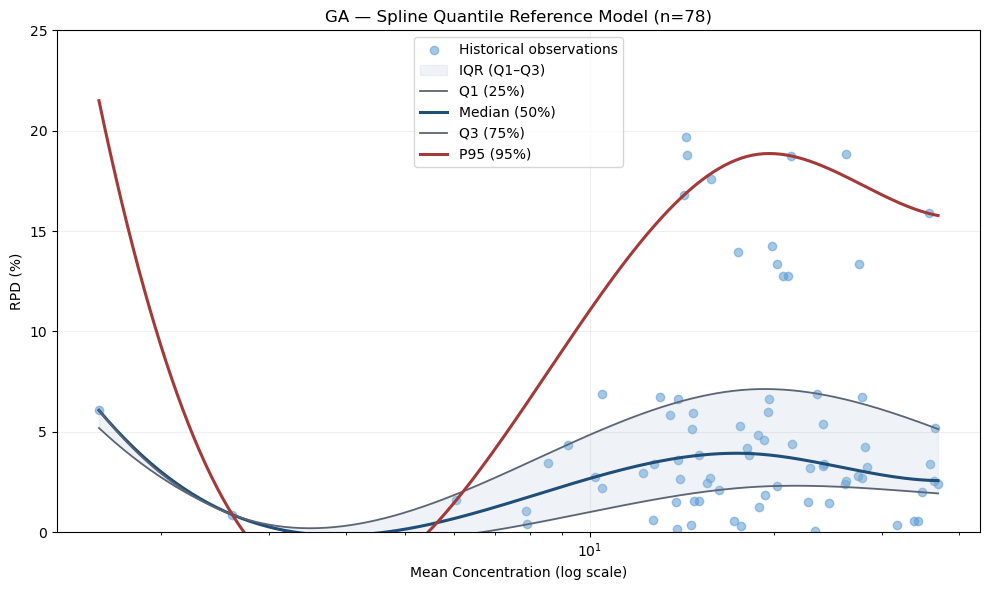

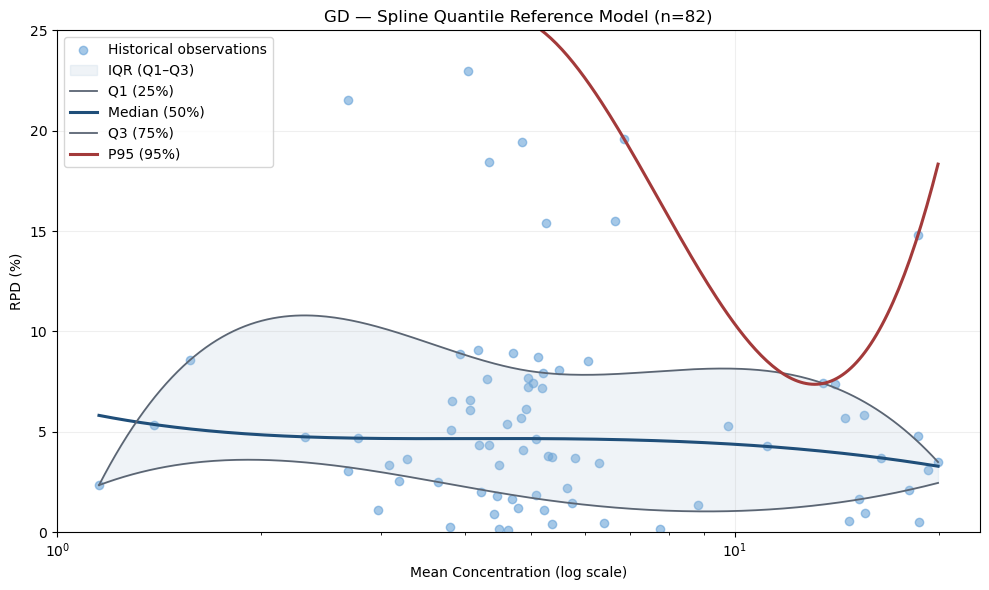

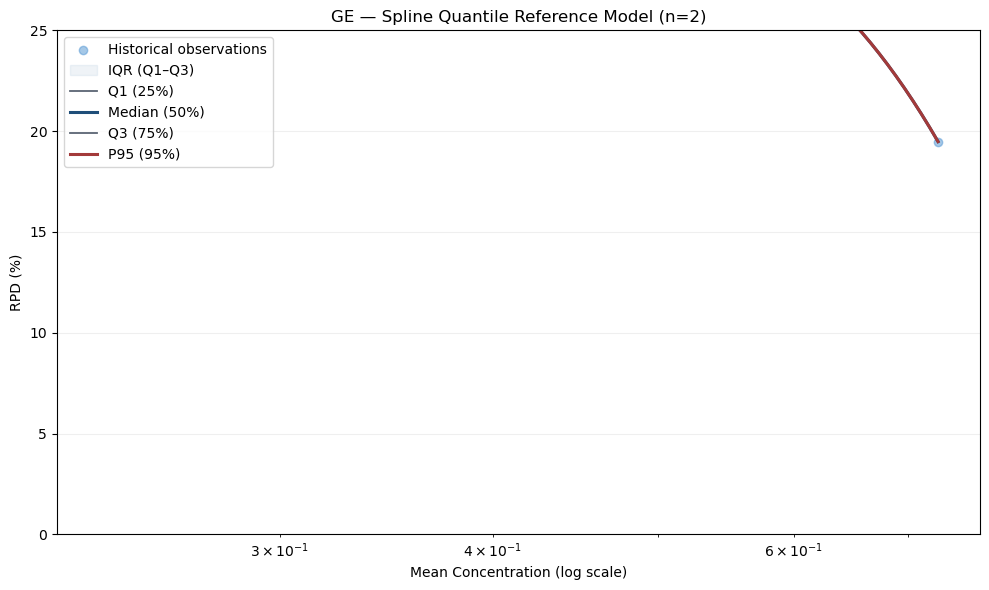

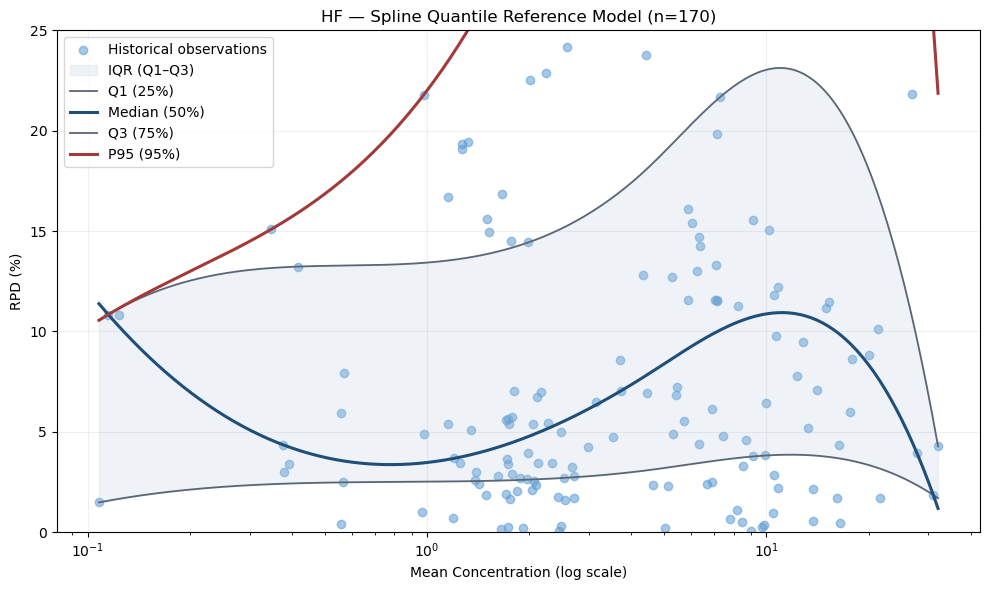

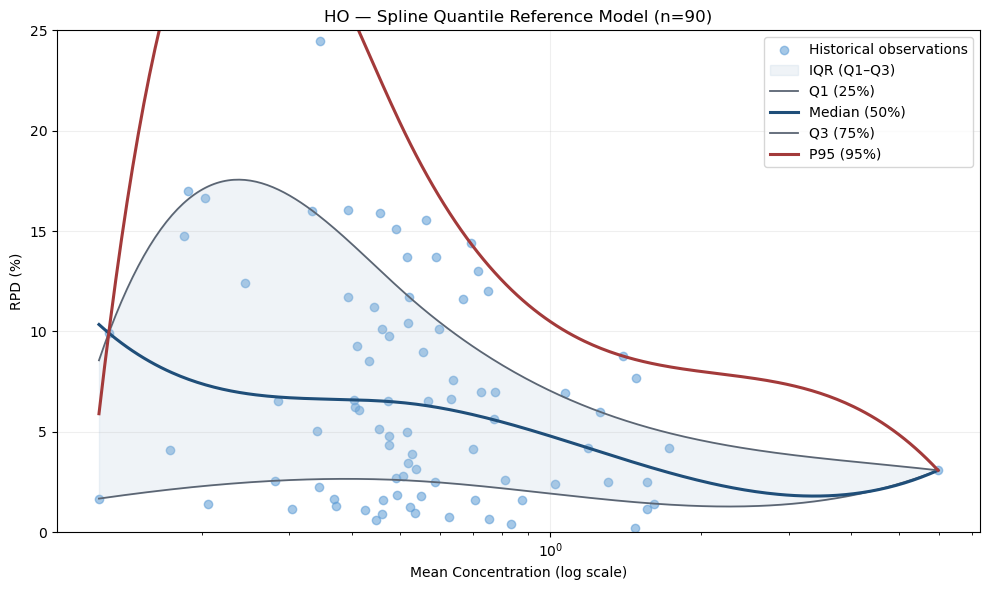

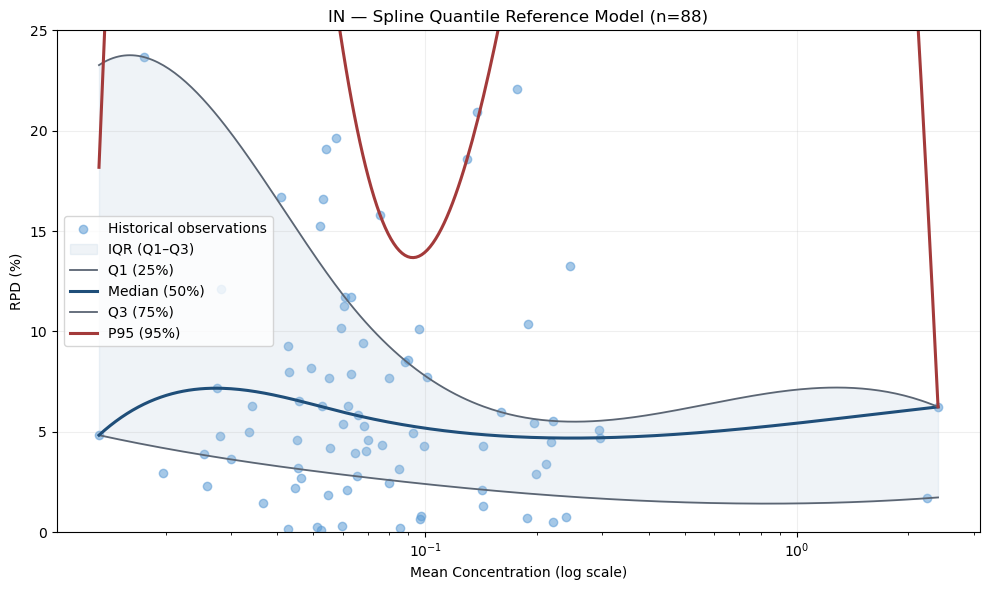

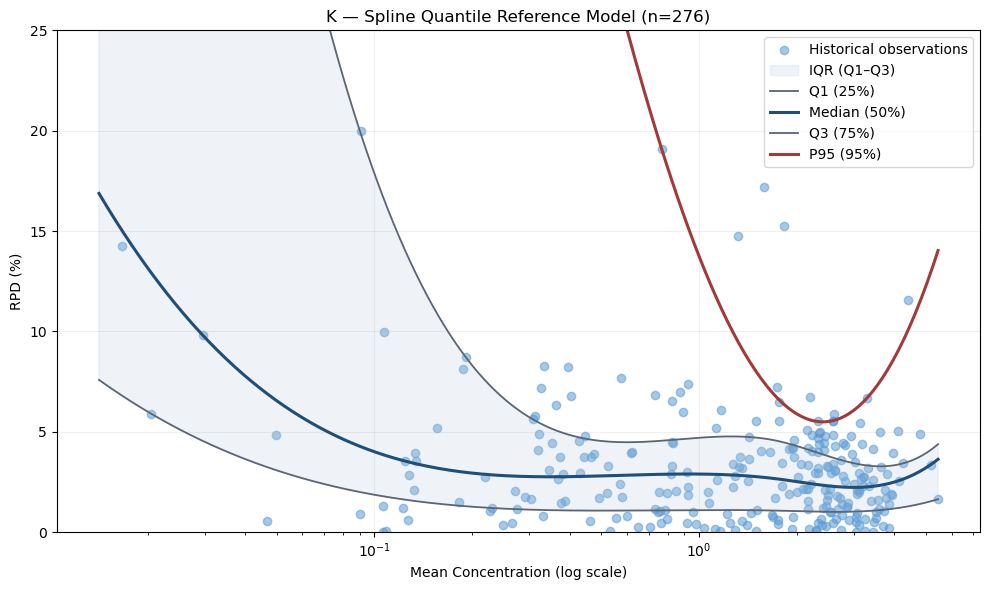

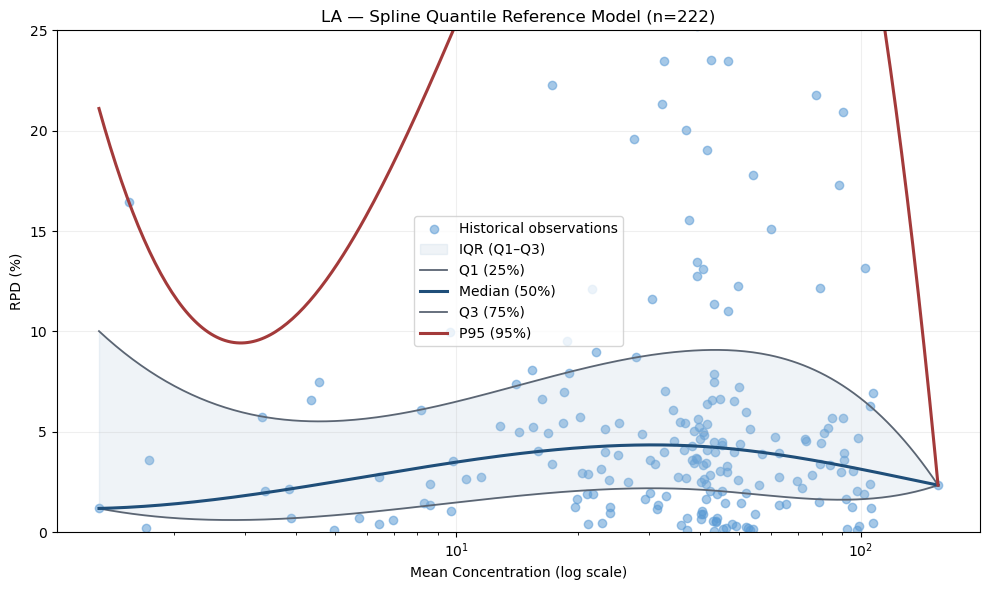

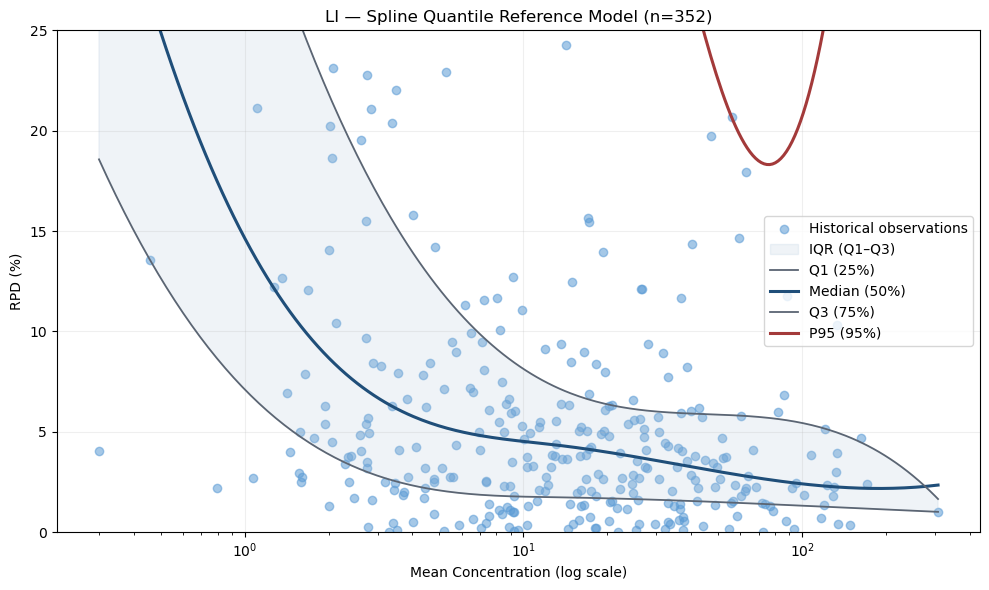

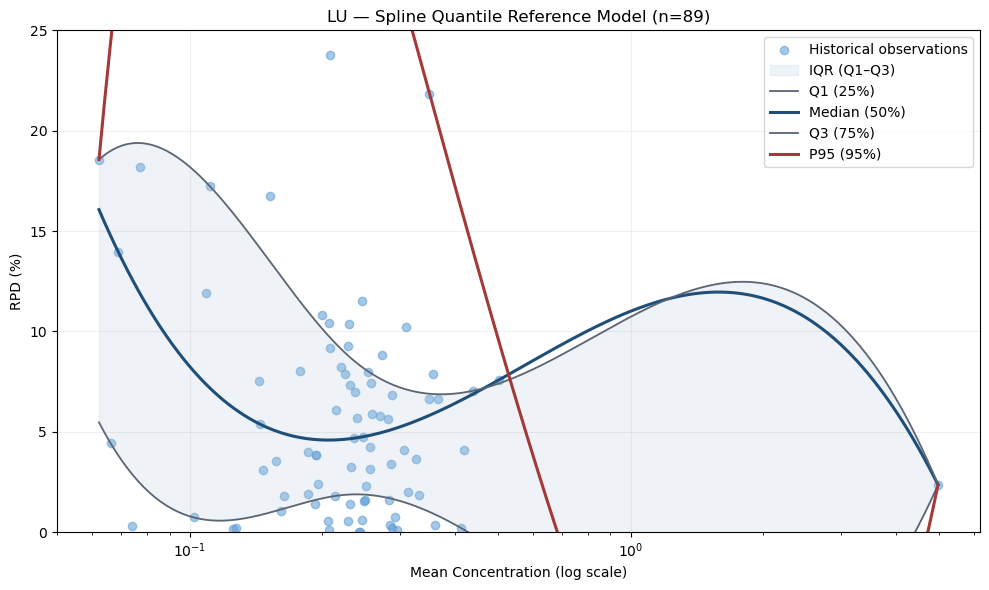

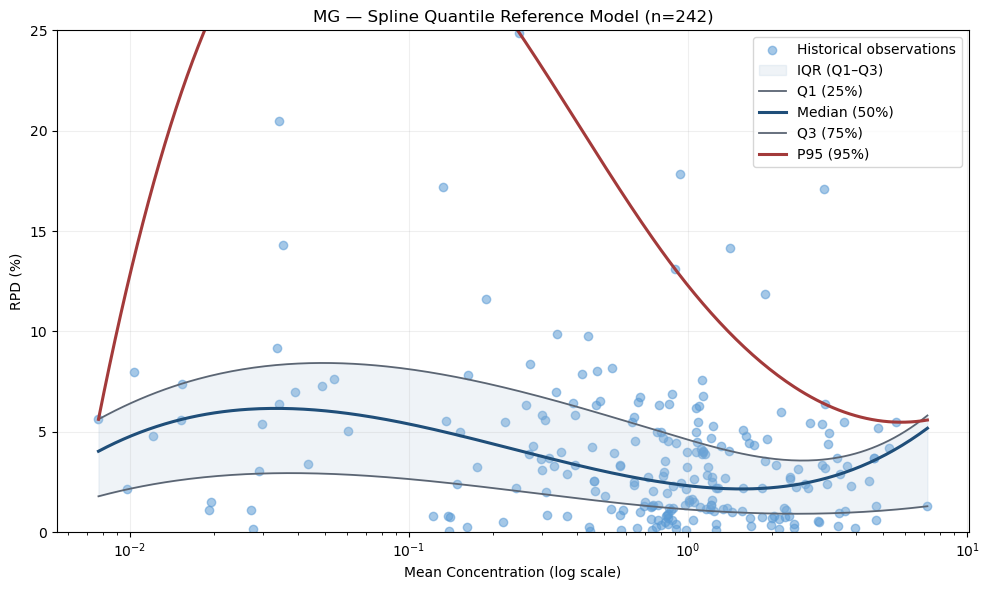

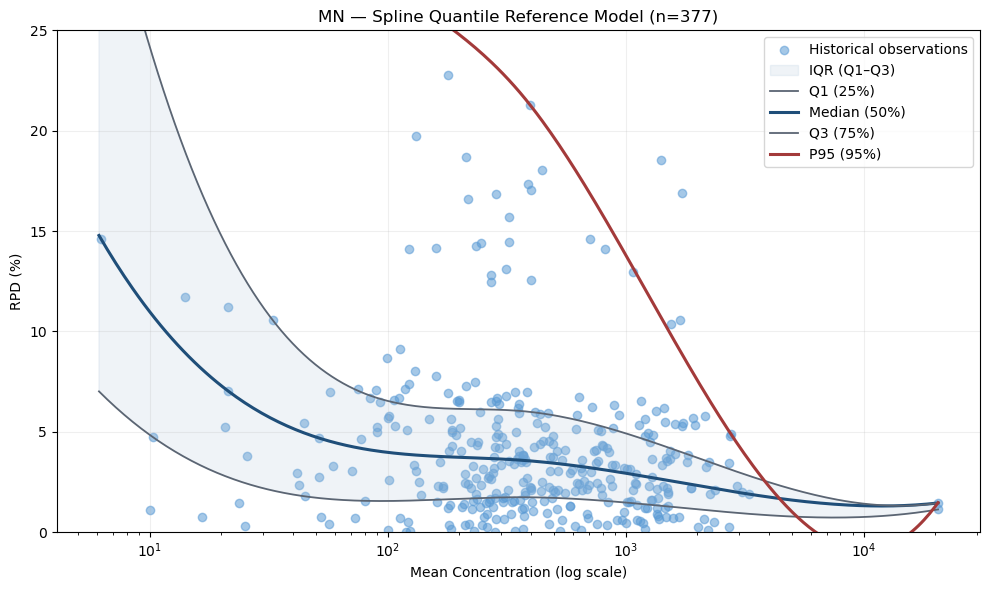

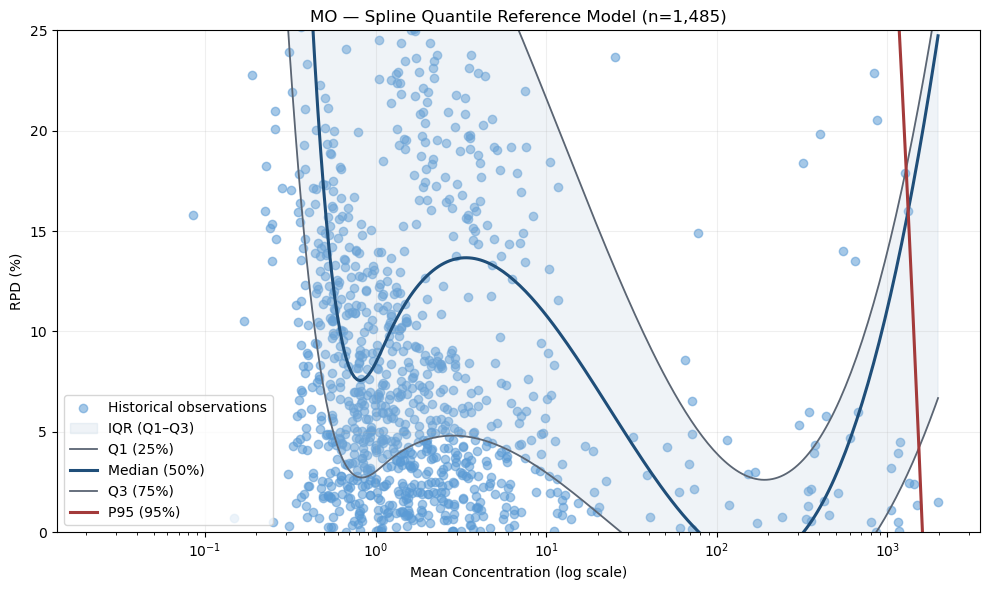

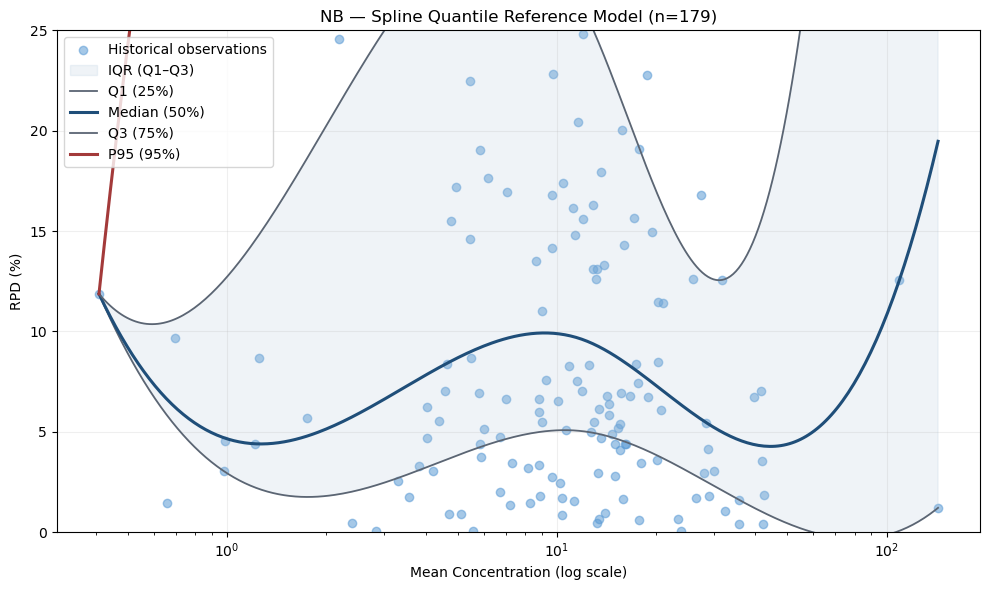

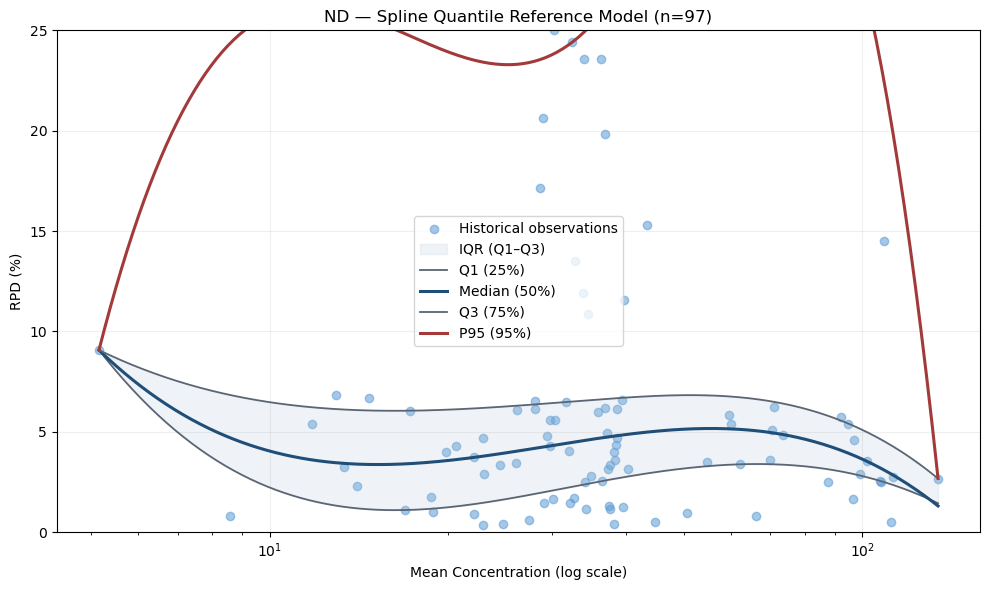

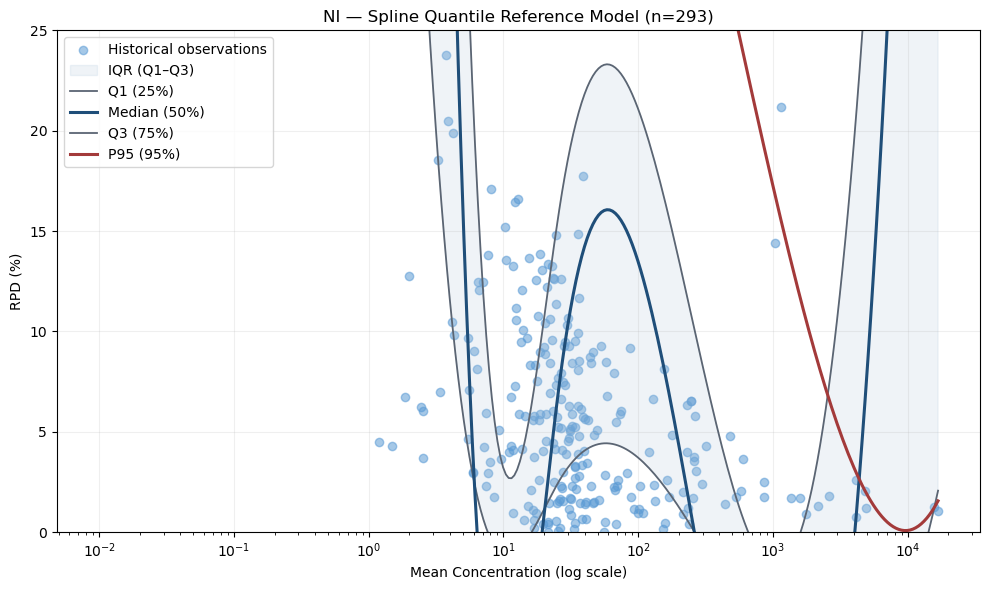

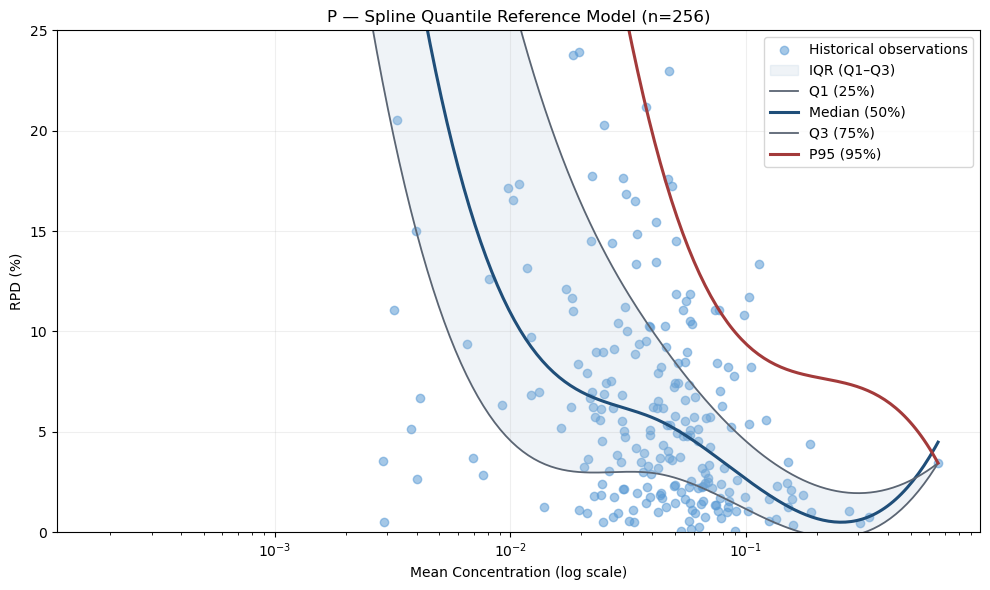

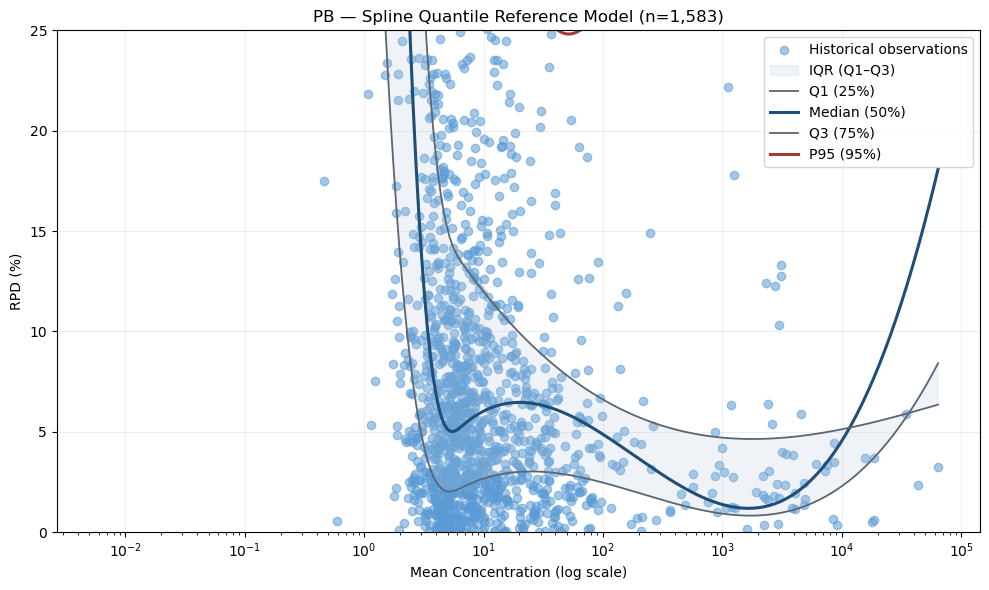

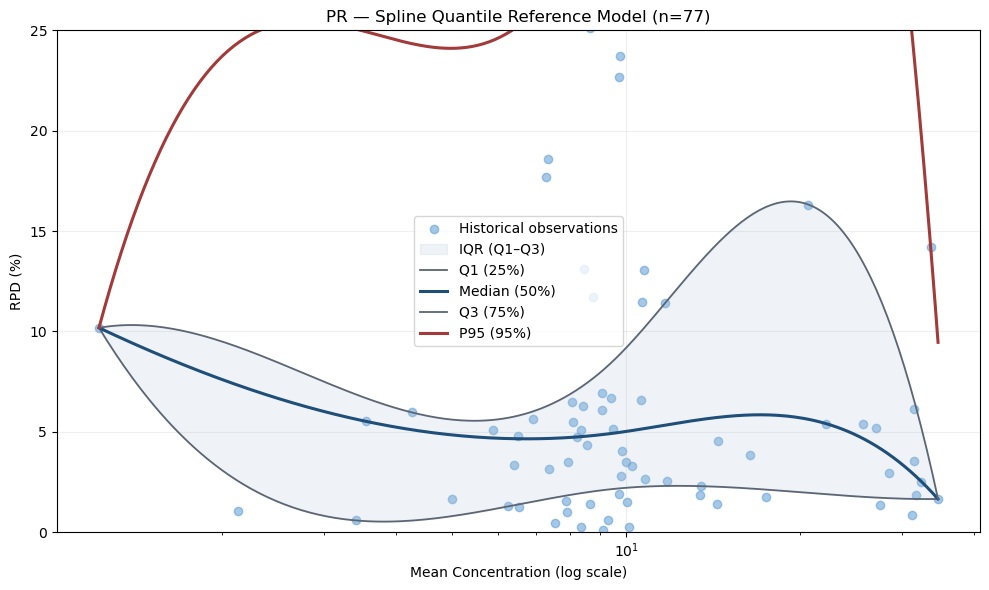

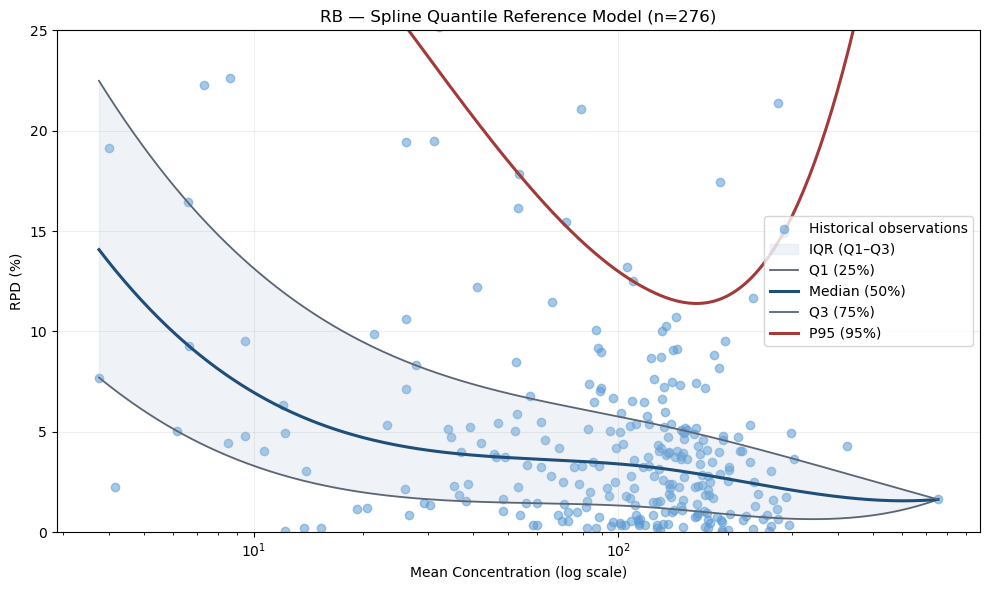

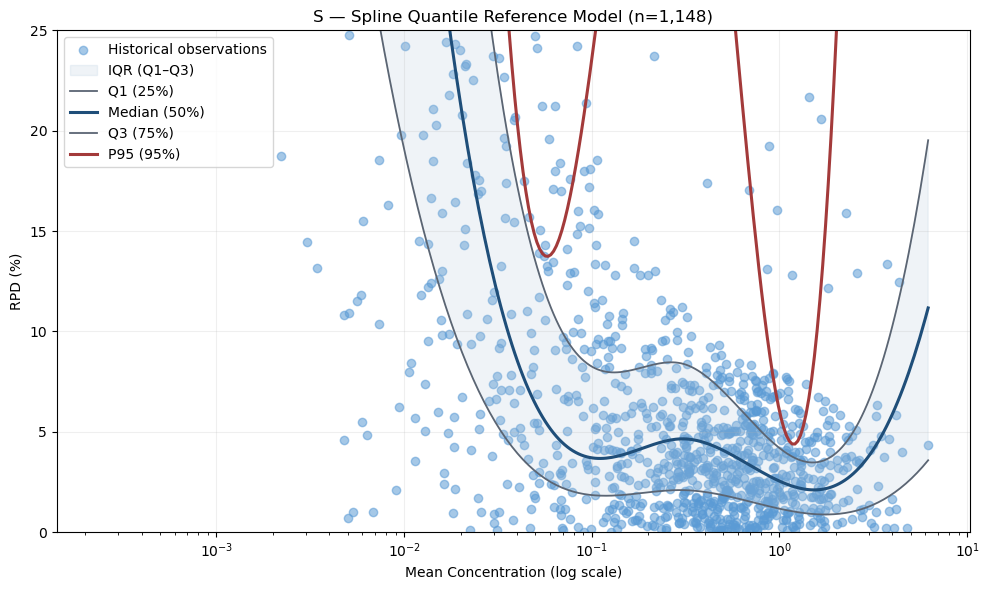

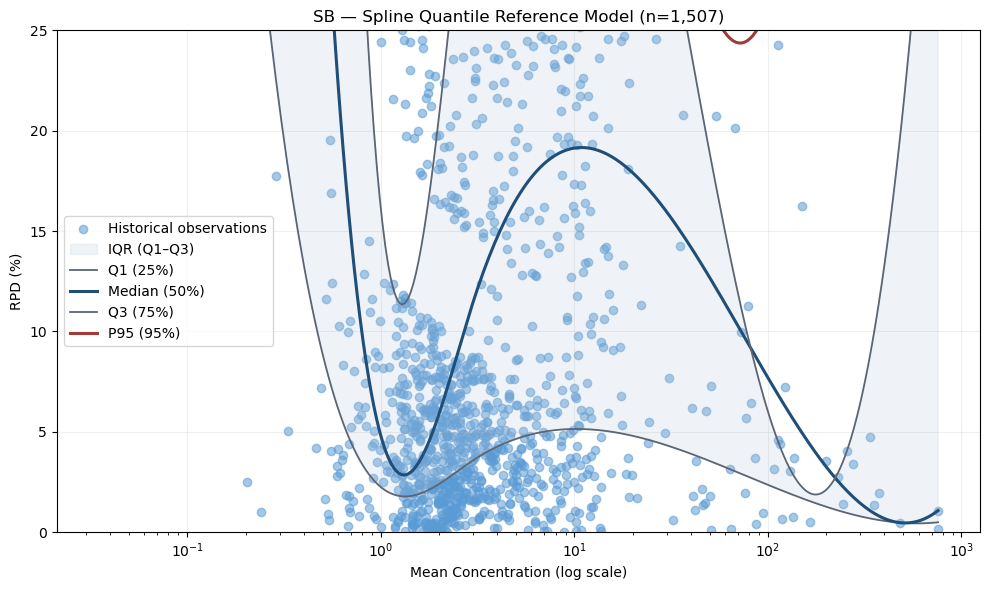

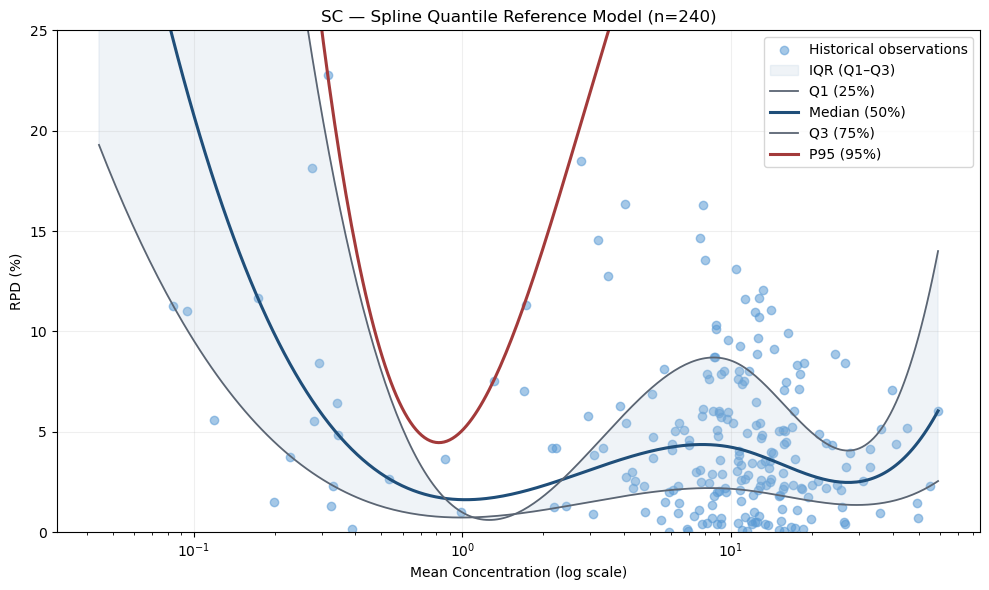

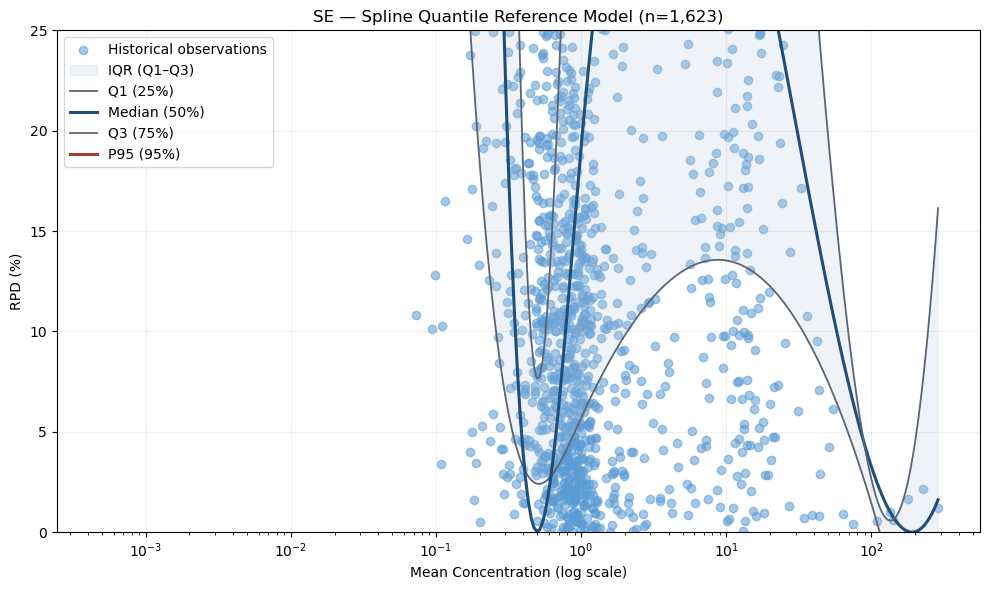

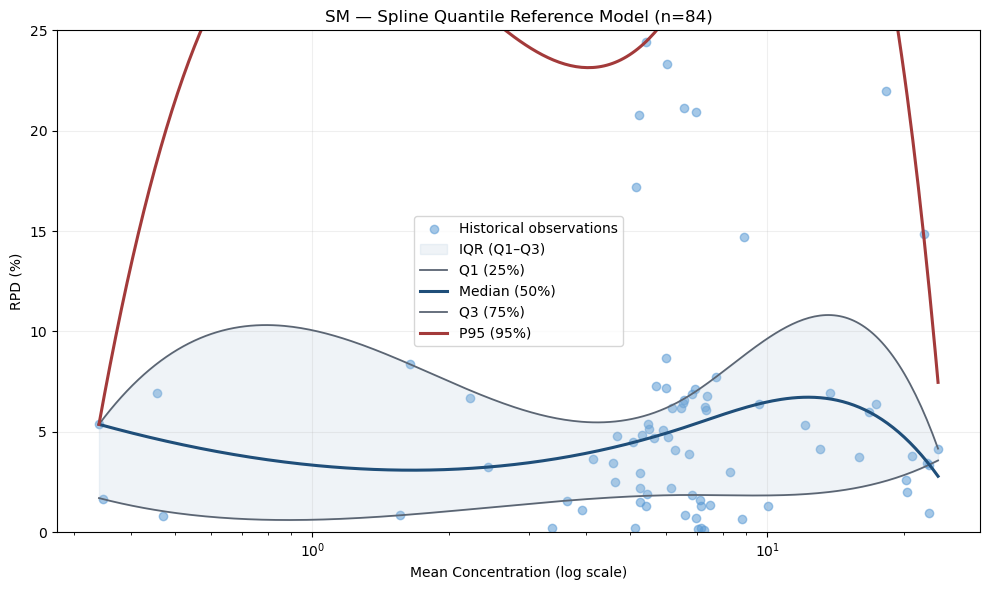

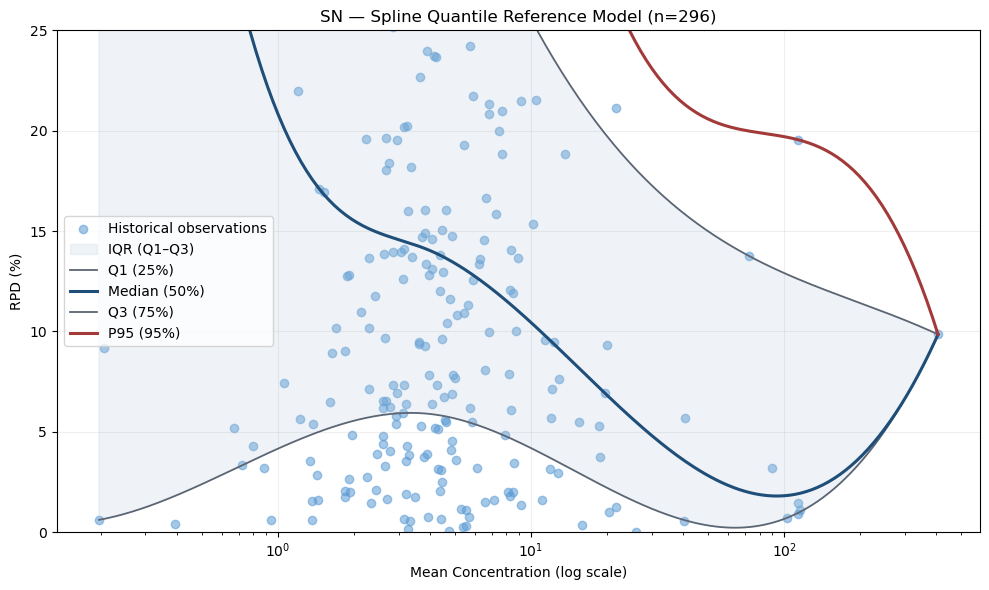

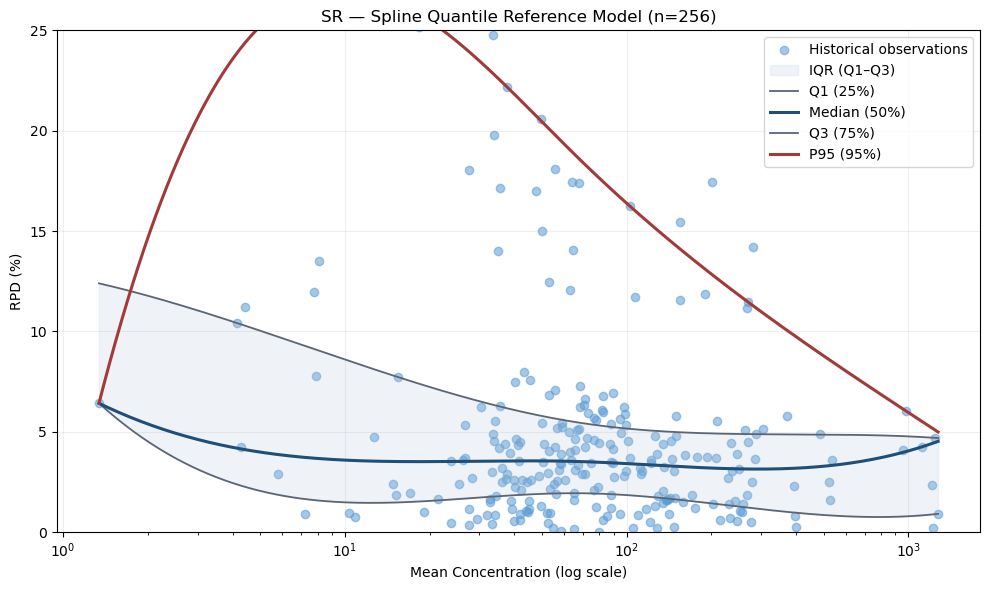

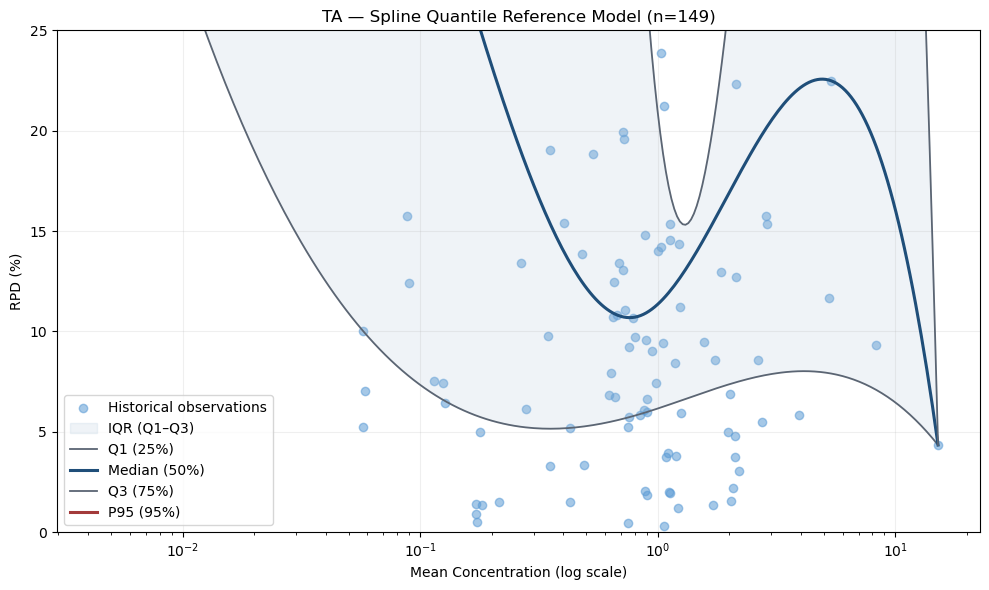

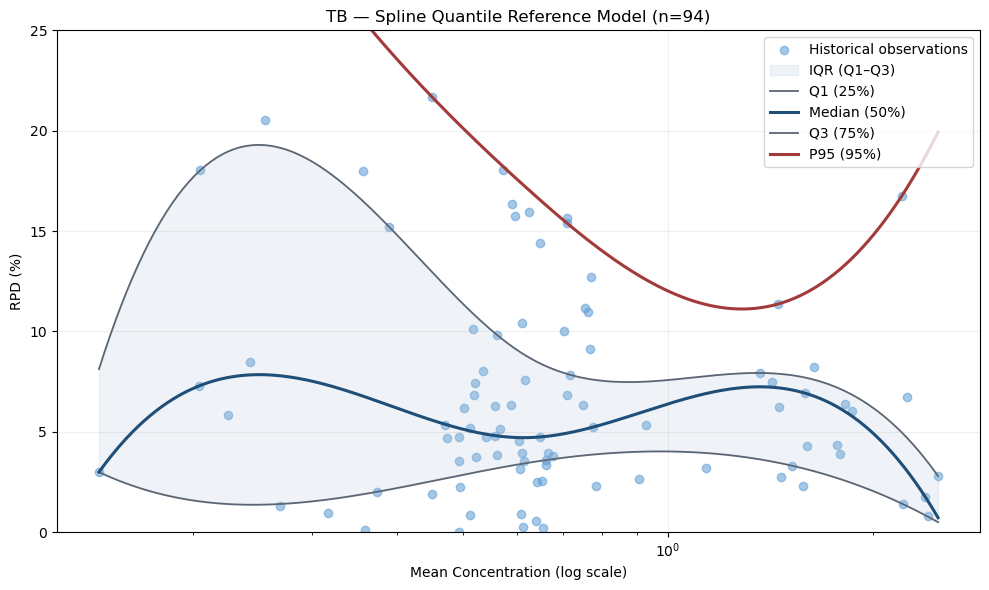

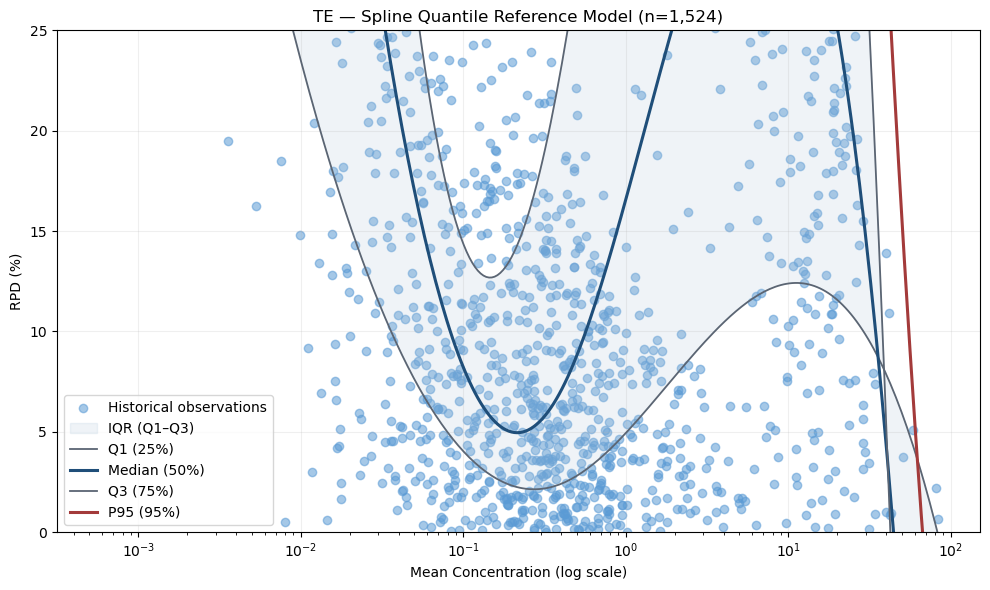

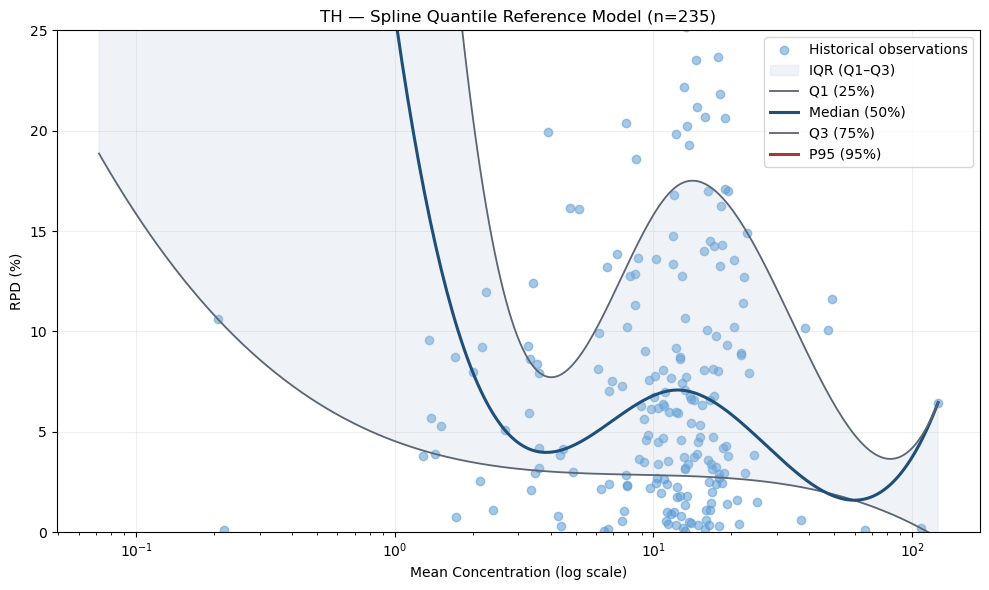

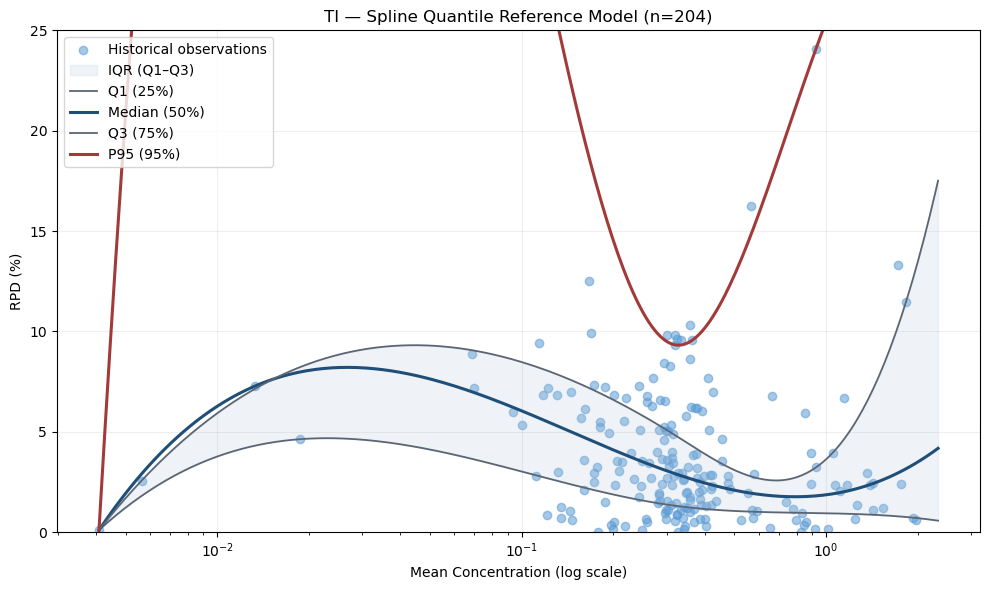

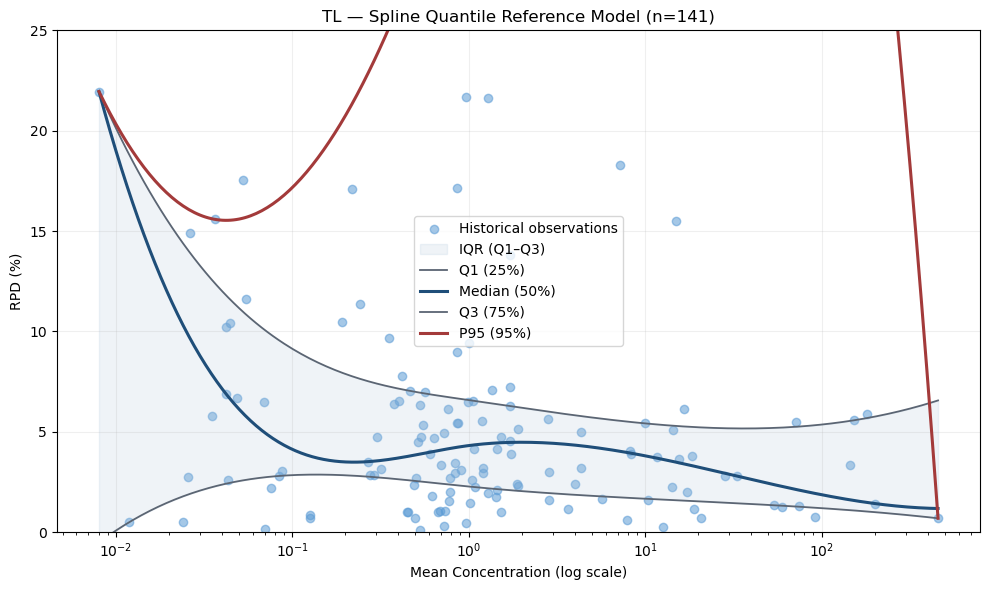

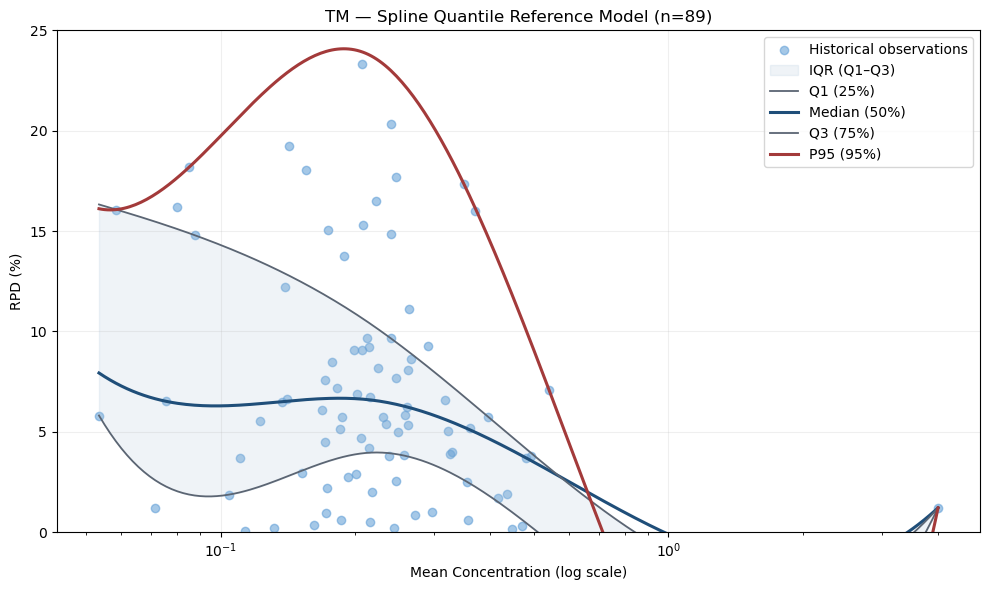

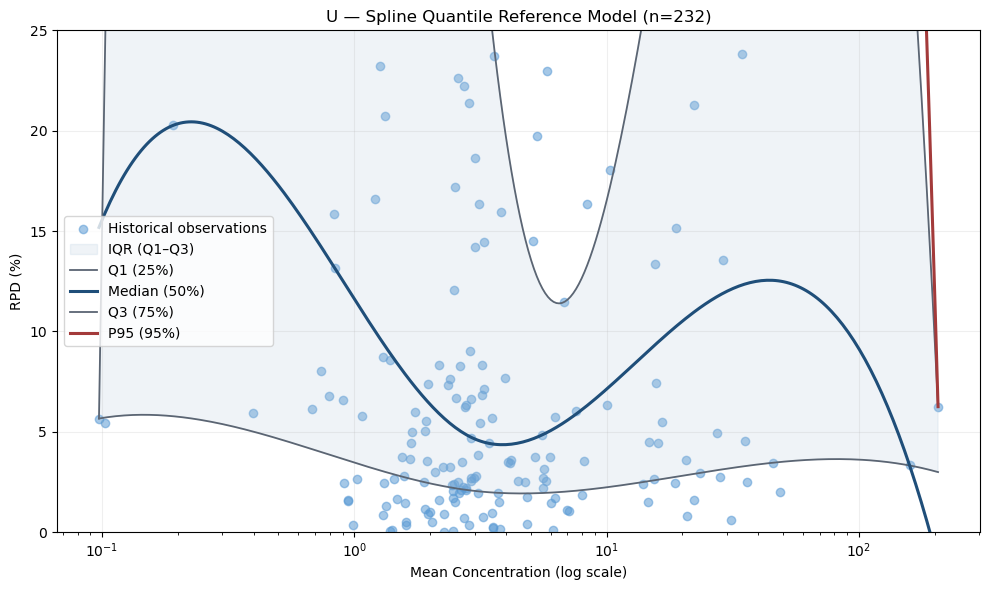

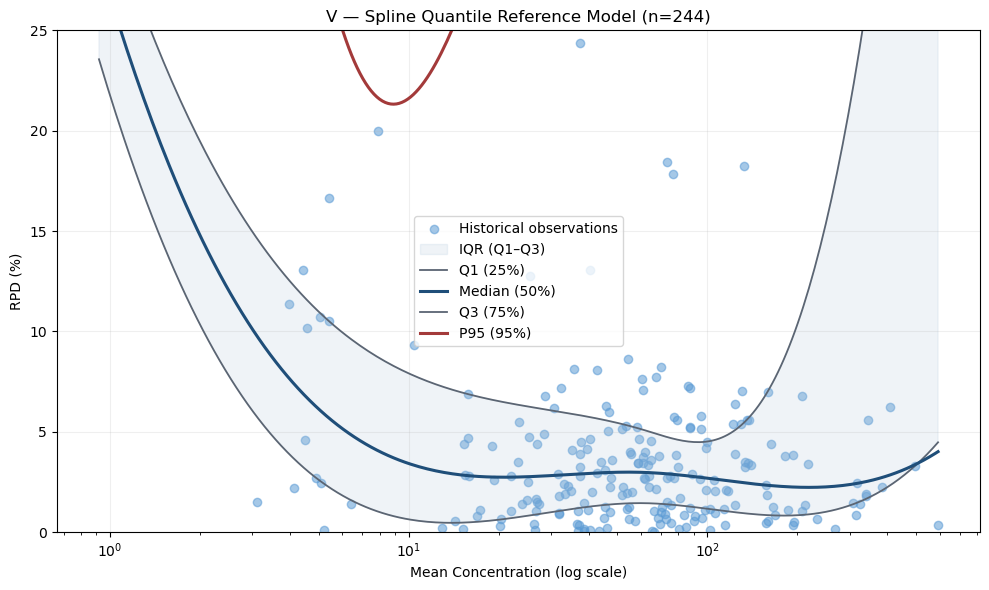

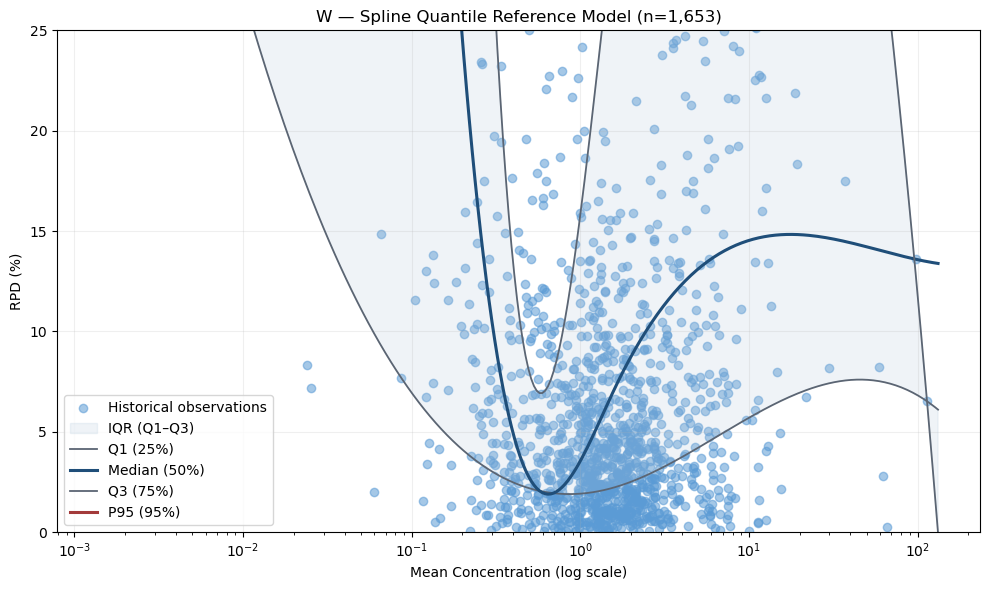

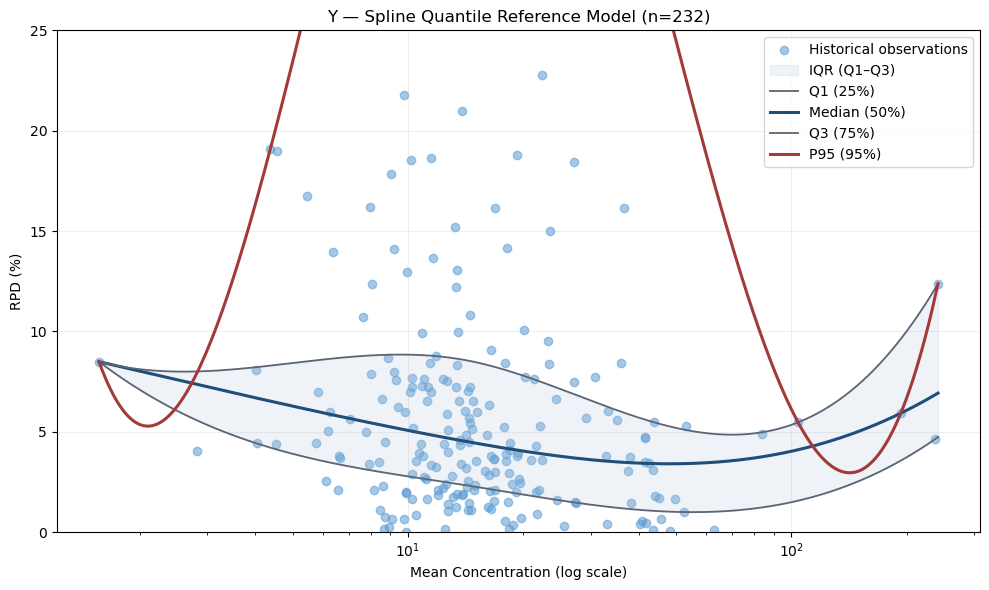

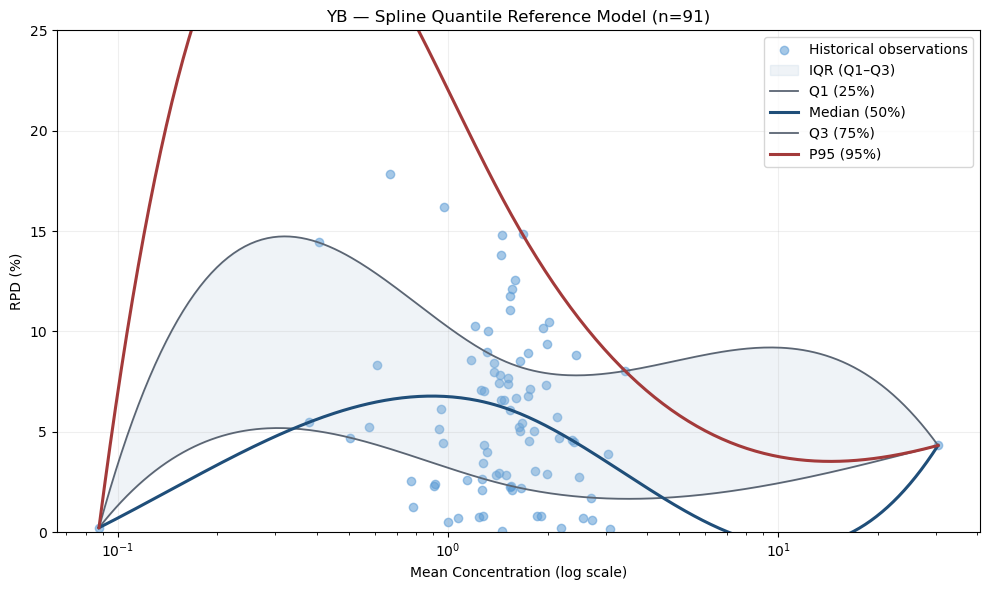

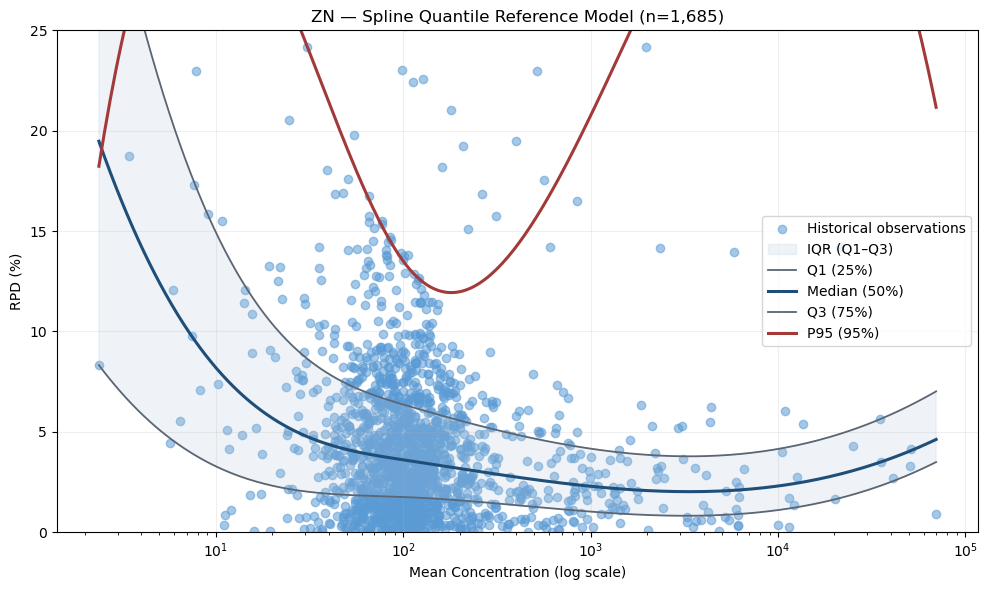

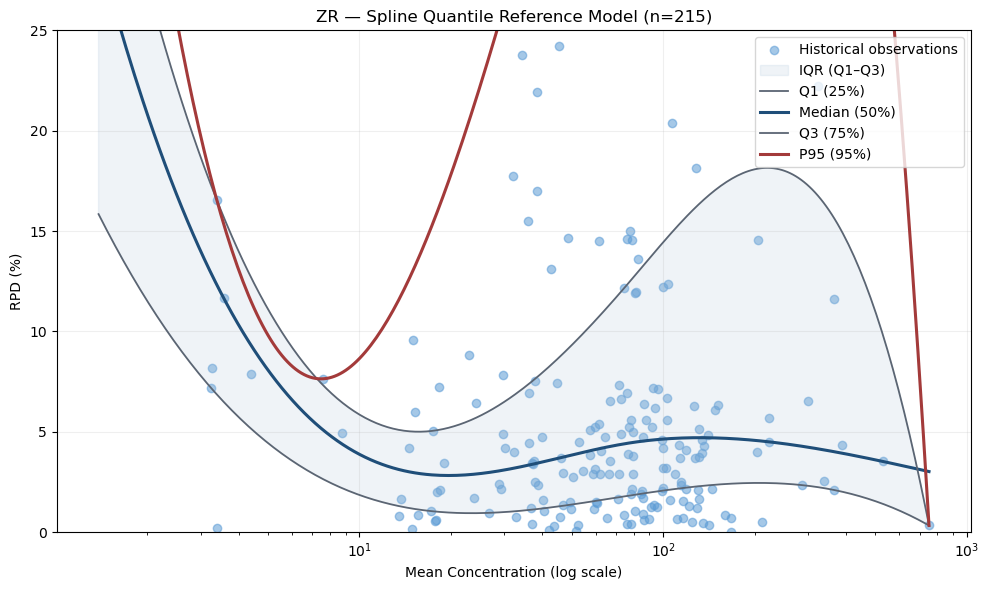

In [14]:
# Plot spline quantile reference model for each analyte

for analyte in MODEL_ANALYTES:

    # Historical observations for this analyte
    df_plot = (
        df_reference[
            df_reference["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    # Reference model predictions for this analyte
    pred_plot = (
        reference_model_df[
            reference_model_df["ANALYTE_CODE"] == analyte
        ]
        .copy()
        .sort_values("MEAN_CONC")
    )

    # ---------------------------------------------------------
    # Plot reference model
    # ---------------------------------------------------------

    plt.figure(figsize=(10, 6))

    # Historical observations
    plt.scatter(
        df_plot["MEAN_CONC"],
        df_plot["RPD"],
        alpha=0.55,
        color=OBS_COLOUR,
        label="Historical observations"
    )

    # Interquartile reference band
    plt.fill_between(
        pred_plot["MEAN_CONC"],
        pred_plot["Q25"],
        pred_plot["Q75"],
        color=IQR_COLOUR,
        alpha=0.20,
        label="IQR (Q1–Q3)"
    )

    # Q1
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q25"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        label="Q1 (25%)"
    )

    # Median
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q50"],
        color=MEDIAN_COLOUR,
        linewidth=2.2,
        label="Median (50%)"
    )

    # Q3
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q75"],
        color=QUANTILE_COLOUR,
        linewidth=1.3,
        label="Q3 (75%)"
    )

    # P95 upper reference
    plt.plot(
        pred_plot["MEAN_CONC"],
        pred_plot["Q95"],
        color=P95_COLOUR,
        linewidth=2.2,
        label="P95 (95%)"
    )

    # Chart formatting
    plt.xscale("log")
    plt.ylim(0, 25)

    plt.xlabel("Mean Concentration (log scale)")
    plt.ylabel("RPD (%)")

    plt.title(
        f"{analyte} — Spline Quantile Reference Model "
        f"(n={len(df_plot):,})"
    )

    plt.legend()
    plt.grid(alpha=0.20)

    plt.tight_layout()
    plt.show()
    

In [15]:
# Persist historical reference model

from pathlib import Path

# Root-level repository data/reference directory
OUTPUT_DIR = Path("../data/reference")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "REP_historical_reference_model.csv"

# Write reference model
reference_model_df.to_csv(
    OUTPUT_FILE,
    index=False
)

# Confirm persisted output
print("Reference model saved to: data/reference/REP_historical_reference_model.csv")
print(f"Rows written: {len(reference_model_df):,}")
print(
    f"Analytes written: "
    f"{reference_model_df['ANALYTE_CODE'].nunique()}"
)


Reference model saved to: data/reference/REP_historical_reference_model.csv
Rows written: 17,400
Analytes written: 58
